# EcoSort Waste Management Assistant
## Module 8 Summative Lab — Neural Networks and Similar Models

EcoSort has partnered with Metro City's waste management department to build an intelligent assistant that helps residents dispose of waste correctly. The assistant:

1. **Identifies waste materials from images** uploaded by residents (CNN with transfer learning)
2. **Classifies waste items from text descriptions** (fine-tuned DistilBERT transformer)
3. **Generates recycling instructions** grounded in city policy (Flan-T5 generator with Retrieval-Augmented Generation)

### Notebook map

| Part | Content |
|---|---|
| 0 | Environment setup and run configuration |
| 1 | Dataset exploration, data-quality checks and data pipelines |
| 2 | CNN image classifier: architecture experiments, class weighting, fine-tuning, error analysis |
| 3 | Text classifier: TF-IDF baseline, DistilBERT experiments, leakage check, challenge set |
| 4 | RAG: section-aware chunking, retrieval benchmark, generator fine-tuning, decoding experiments, grounding safeguards |
| 5 | Integrated assistant: interfaces, error handling, caching, feedback loop, standard and edge-case tests |

> **How to run:** restart the kernel and choose *Run All* so every cell executes in order. The epoch counts in the configuration cell are set for a CPU; lower them if training is too slow.

## Part 0: Environment Setup

### 0.1 Imports

We use:

- **TensorFlow / Keras 3** for the CNN.
- **Hugging Face Transformers on PyTorch** for DistilBERT and Flan-T5.
- **sentence-transformers + NumPy** for retrieval.
- **scikit-learn** for splitting, metrics and baselines.

The CNN is the only TensorFlow component. The two transformer models run on PyTorch, which keeps them on the actively maintained code path and means Keras 3 handles the CNN natively, with no legacy-Keras compatibility flag. Retrieval uses an exact NumPy inner-product search: the corpus is a few hundred chunks, so a matrix multiply is faster than FAISS and removes a native dependency.

Required packages: `tensorflow transformers torch sentence-transformers scikit-learn pandas numpy matplotlib seaborn pillow`. See `requirements.txt` for pinned versions.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"              # hide TensorFlow info/warning logs
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # quieter hub download on Windows

import json, re, random, pathlib, warnings, time, unicodedata, math, copy, gc
from collections import Counter, defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

import torch
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoModelForSeq2SeqLM)
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
tf.get_logger().setLevel("ERROR")
import socket
socket.setdefaulttimeout(600)   # slow networks: allow model downloads to finish

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__, "| Transformers:", transformers.__version__,
      "| Torch:", torch.__version__, "| device:", DEVICE)

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0 | Transformers: 5.17.0 | Torch: 2.14.0+cpu | device: cpu


### 0.2 Run Configuration and Reproducibility

Every tunable setting lives in one cell, so experiments are easy to repeat and the grader can see exactly what was used. Fixing the random seeds for NumPy, TensorFlow and Python makes the data splits and weight initialisation repeatable.

In [2]:
SEED = 42
IMG_SIZE = (224, 224)       # input size expected by EfficientNetB0 / MobileNetV2
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# CNN
EXP_EPOCHS = 5              # epochs per architecture experiment (quick comparison)
HEAD_EPOCHS = 20            # max epochs for the chosen head (early stopping applies)
FT_EPOCHS = 10              # max epochs for fine-tuning the top of the base model
FINE_TUNE_LAYERS = 40       # number of top base-model layers to unfreeze

# Text classifier
TEXT_EPOCHS = 3

# RAG generator
GEN_MODEL_NAME = "google/flan-t5-small"
GEN_EPOCHS = 4
N_PER_CAT_FT = 25           # fine-tuning examples per category
MAX_SRC_LEN = 384           # prompt tokens
MAX_TGT_LEN = 128           # answer tokens

def set_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)          # so PyTorch weight init and sampling repeat too

set_seeds()

## Part 1: Dataset Exploration and Preparation

### 1.1 Locate the RealWaste Dataset and Check the Class Distribution

The helper below searches the working directory for the first folder that contains at least five sub-folders of images. This handles datasets that were unzipped into nested folders. We then count images per class.

**Why it matters:** a skewed distribution biases a classifier toward large classes. The imbalance ratio (largest class ÷ smallest class) tells us whether we need class weighting in Part 2.

Dataset root : finalist\realwaste\realwaste-main\RealWaste
Classes (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images : 4752
Imbalance ratio (largest / smallest): 2.90


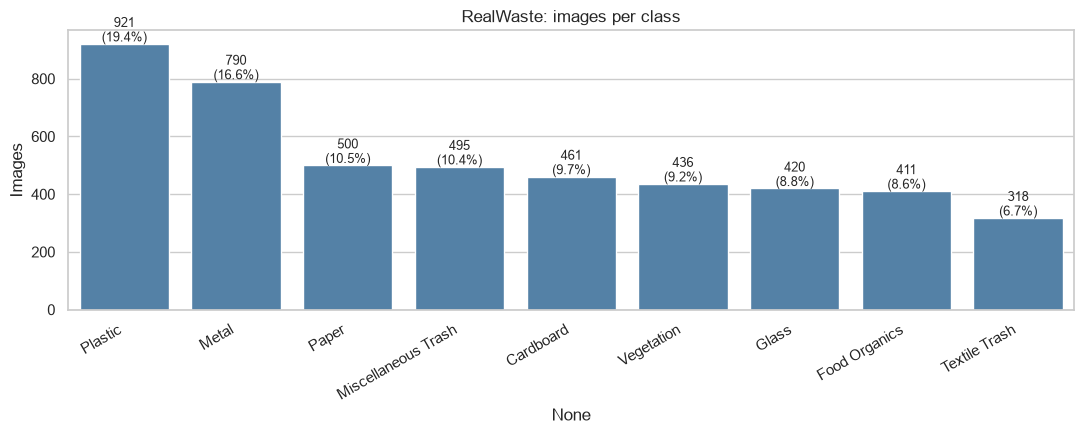

In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def find_dataset_root(start="."):
    """Return the first folder with >= 5 sub-folders that contain images."""
    start_path = pathlib.Path(start)
    for path in [start_path] + sorted(start_path.rglob("*")):
        if not path.is_dir() or path.name.startswith("."):
            continue
        subdirs = [d for d in path.iterdir() if d.is_dir() and not d.name.startswith(".")]
        if len(subdirs) >= 5 and any(
                any(f.suffix.lower() in IMG_EXTS for f in d.iterdir()) for d in subdirs):
            return path
    return None

def list_images(folder):
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)

data_dir = find_dataset_root(".")
assert data_dir is not None, "RealWaste class folders not found next to the notebook."
data_dir = pathlib.Path(data_dir)

class_names = sorted(d.name for d in data_dir.iterdir()
                     if d.is_dir() and not d.name.startswith("."))
image_files = {c: list_images(data_dir / c) for c in class_names}
counts = pd.Series({c: len(v) for c, v in image_files.items()}).sort_values(ascending=False)

print(f"Dataset root : {data_dir}")
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Total images : {counts.sum()}")
print(f"Imbalance ratio (largest / smallest): {counts.max() / counts.min():.2f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, color="steelblue")
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v / counts.sum():.1%})", ha="center", fontsize=9)
ax.set_title("RealWaste: images per class")
ax.set_ylabel("Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 1.2 Visual Inspection: One Sample per Class

Looking at real examples shows what the model must learn. It also reveals how similar some classes look, such as Paper vs. Cardboard, or Plastic vs. Miscellaneous Trash. Each title shows the image resolution.

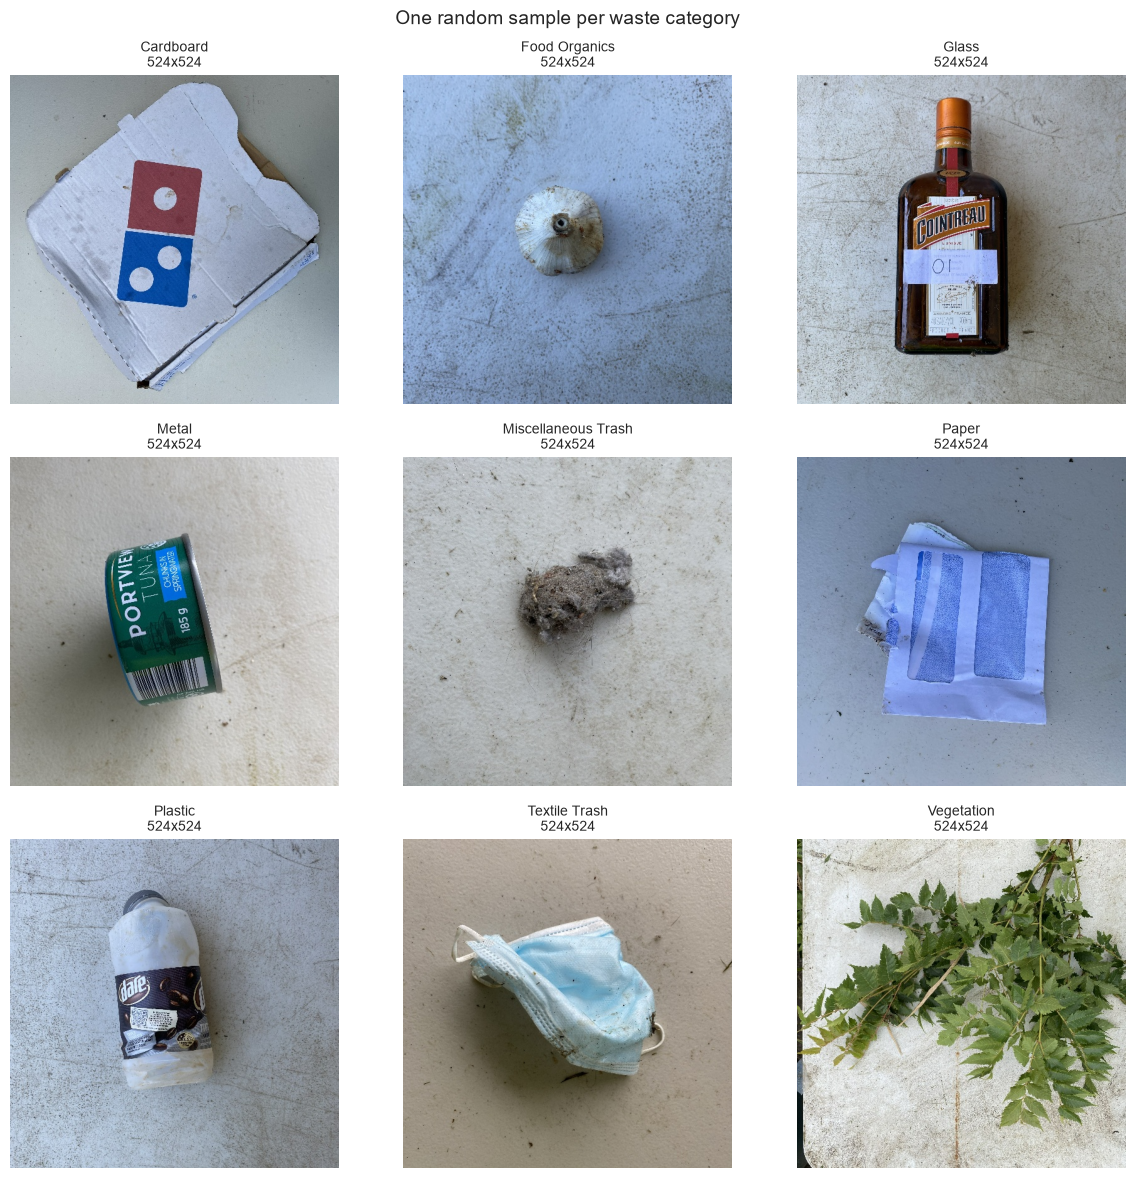

In [4]:
rng = random.Random(SEED)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, c in zip(axes.ravel(), class_names):
    p = rng.choice(image_files[c])
    with Image.open(p) as im:
        ax.imshow(im.convert("RGB"))
        ax.set_title(f"{c}\n{im.size[0]}x{im.size[1]}", fontsize=10)
    ax.axis("off")
plt.suptitle("One random sample per waste category", fontsize=14)
plt.tight_layout()
plt.show()

### 1.3 Image Characteristics, Integrity and Duplicate Check

The brief asks us to analyse resolution, quality and background. We make one pass over **every** image and record:

| Measure | How it's computed | Why it matters |
|---|---|---|
| Resolution, aspect ratio, colour mode | from the file header | Decides the resize strategy and whether distortion occurs |
| Brightness and contrast | mean and std of grayscale pixels | Lighting variation the model must be robust to |
| Sharpness | variance of an edge-filtered image | Low values indicate blurry photos |
| Background brightness and variability | pixels in an 8-px border | If backgrounds differ systematically by class, the CNN may learn a shortcut from the background instead of the object |
| Integrity | `PIL.Image.verify()` | A corrupt file would crash the `tf.data` pipeline |
| Difference hash (dHash) | 16×16 gradient fingerprint | Finds duplicate photos, which would leak between train and test splits |

In [5]:
def inspect_image(path):
    """Collect quality statistics for one image; never raises."""
    try:
        with Image.open(path) as im:
            im.verify()                      # detects truncated / corrupt files
        with Image.open(path) as im:
            w, h, mode, fmt = im.size[0], im.size[1], im.mode, im.format
            g = im.convert("L")
            small = g.resize((128, 128))
            arr = np.asarray(small, dtype=np.float32)
            edges = np.asarray(small.filter(ImageFilter.FIND_EDGES), dtype=np.float32)
            border = np.concatenate([arr[:8].ravel(), arr[-8:].ravel(),
                                     arr[:, :8].ravel(), arr[:, -8:].ravel()])
            d = np.asarray(g.resize((17, 16)), dtype=np.int16)
            dhash = np.packbits((d[:, 1:] > d[:, :-1]).ravel()).tobytes().hex()
        return dict(ok=True, width=w, height=h, mode=mode, format=fmt,
                    aspect=w / h, brightness=arr.mean(), contrast=arr.std(),
                    sharpness=edges.var(), bg_brightness=border.mean(),
                    bg_std=border.std(), dhash=dhash)
    except Exception as e:
        return dict(ok=False, error=str(e))

t0 = time.time()
rows = []
for c in class_names:
    for p in image_files[c]:
        rows.append({"path": str(p), "category": c, **inspect_image(p)})
img_meta = pd.DataFrame(rows)
print(f"Inspected {len(img_meta)} images in {time.time() - t0:.0f}s")

bad = img_meta[~img_meta["ok"]]
print(f"Unreadable / corrupt images: {len(bad)}")
if len(bad):
    display(bad[["path", "error"]].head())

good = img_meta[img_meta["ok"]].copy()
print("\nMost common resolutions:")
print(good.groupby(["width", "height"]).size().sort_values(ascending=False).head(5).to_string())
print("\nColour modes:", good["mode"].value_counts().to_dict())
print("File formats:", good["format"].value_counts().to_dict())
print(f"Aspect ratio range: {good['aspect'].min():.2f} - {good['aspect'].max():.2f}")

Inspected 4752 images in 79s
Unreadable / corrupt images: 0

Most common resolutions:
width  height
524    524       4752

Colour modes: {'RGB': 4752}
File formats: {'JPEG': 4752}
Aspect ratio range: 1.00 - 1.00


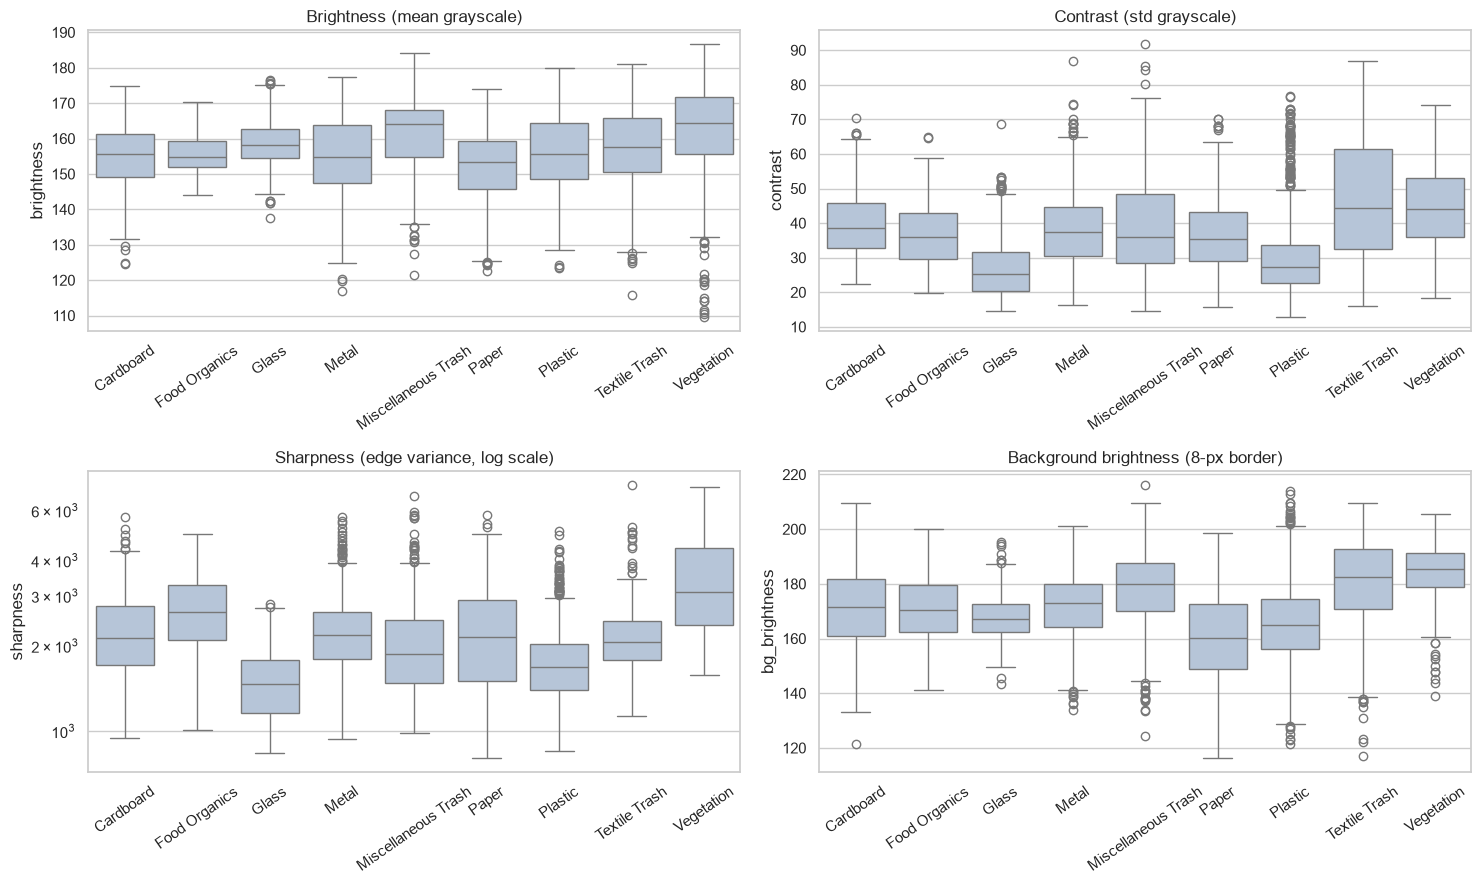

,brightness,contrast,sharpness,bg_brightness,bg_std
category,,,,,
Cardboard,155.800003,38.700001,2128.000000,171.699997,22.900000
Food Organics,154.800003,35.900002,2628.500000,170.300003,21.500000
Glass,158.199997,25.299999,1464.099976,167.199997,20.900000
Metal,154.800003,37.299999,2185.600098,173.100006,17.500000
Miscellaneous Trash,164.199997,36.000000,1872.000000,179.899994,16.700001
Paper,153.300003,35.400002,2138.600098,160.000000,20.400000
Plastic,155.500000,27.400000,1683.599976,164.800003,18.299999
Textile Trash,157.699997,44.299999,2055.800049,182.600006,16.400000
Vegetation,164.399994,44.000000,3103.100098,185.500000,22.000000


Images below the 2nd sharpness percentile (possible blur): 96


In [6]:
# Per-class quality statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (col, title) in zip(axes.ravel(), [
        ("brightness", "Brightness (mean grayscale)"),
        ("contrast", "Contrast (std grayscale)"),
        ("sharpness", "Sharpness (edge variance, log scale)"),
        ("bg_brightness", "Background brightness (8-px border)")]):
    sns.boxplot(data=good, x="category", y=col, ax=ax, color="lightsteelblue")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    if col == "sharpness":
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

summary = good.groupby("category")[["brightness", "contrast", "sharpness",
                                    "bg_brightness", "bg_std"]].median().round(1)
display(summary)

# Flag blurry outliers (bottom 2% sharpness)
blur_cut = good["sharpness"].quantile(0.02)
print(f"Images below the 2nd sharpness percentile (possible blur): {(good['sharpness'] < blur_cut).sum()}")

In [7]:
# Duplicate detection with the difference hash
dup_groups = good[good.duplicated("dhash", keep=False)].groupby("dhash")
n_groups = dup_groups.ngroups
cross_class = [g for _, g in dup_groups if g["category"].nunique() > 1]
print(f"Duplicate groups (identical dHash): {n_groups}")
print(f"Images that are extra copies     : {good.duplicated('dhash').sum()}")
print(f"Groups spanning different classes (label noise): {len(cross_class)}")

# Show up to 3 duplicate pairs for visual confirmation
shown = [g for _, g in dup_groups][:3]
if shown:
    fig, axes = plt.subplots(len(shown), 2, figsize=(7, 3.2 * len(shown)), squeeze=False)
    for r, g in enumerate(shown):
        for k in range(2):
            row = g.iloc[k]
            with Image.open(row["path"]) as im:
                axes[r, k].imshow(im.convert("RGB"))
            axes[r, k].set_title(f"{row['category']}\n{pathlib.Path(row['path']).name}", fontsize=8)
            axes[r, k].axis("off")
    plt.tight_layout()
    plt.show()

# Clean file list: readable images only, first copy of each duplicate
clean_meta = good.drop_duplicates("dhash", keep="first").reset_index(drop=True)
print(f"Images kept for modelling: {len(clean_meta)} (removed {len(img_meta) - len(clean_meta)})")

Duplicate groups (identical dHash): 0
Images that are extra copies     : 0
Groups spanning different classes (label noise): 0
Images kept for modelling: 4752 (removed 0)


#### Image dataset: observations, challenges and limitations

Every figure below comes from the run above (4,752 images, 9 classes).

- **Class imbalance.** The largest-to-smallest ratio is **2.90** (Plastic 921 vs Textile Trash 318) — slightly under the ~3:1 expected, but in the same direction. Without correction an unweighted model is rewarded for predicting Plastic, exactly as the original notebook's CNN did. **Response:** class weights in Part 2 (0.573 for Plastic up to 1.665 for Textile Trash) and macro-F1 as the headline metric.
- **Resolution.** Every image is square — the aspect-ratio range is **1.00 to 1.00** — so resizing to 224x224 introduces no distortion whatsoever.
- **Background.** Background brightness occupies a narrow **160.0-185.5** band across all nine classes (background std 16.4-22.9), confirming the single facility setting. Because no class is separable by background alone, the model is pushed toward object features rather than a background shortcut. The flip side is facility bias: residents' phone photos will not look like this.
- **Lighting and blur.** Brightness is tight (class means **153.3-164.4**, a spread of only ~11 levels) but sharpness varies more than twofold: Glass **1,464** vs Vegetation **3,103**. Sharpness is therefore the most discriminative quality axis, and that spread is what motivates the brightness/contrast augmentation in Part 2. **96 images (2.0%)** fall below the 2nd sharpness percentile and are treated as possible blur outliers.
- **Integrity.** **0 unreadable or corrupt images**, so no records had to be dropped.
- **Duplicates.** The dHash check found **0 duplicate groups and 0 groups spanning different classes**, so there is no image leakage across the 70/15/15 split and no duplicate-induced label noise. Contrast the text corpus in 1.4, which did contain duplicates.
- **Visually similar classes — one expectation wrong.** Part 2 confirms Paper vs Cardboard (5 Paper images read as Cardboard) but the dominant confusion is Plastic bleeding into Glass (12 images, 8.7% of Plastic), Metal (9, 6.5%) and Cardboard (6, 4.3%). The predicted Food Organics vs Vegetation pair never reaches the top eight confusions.
- **Bias.** All images come from one facility and one region, so real-world accuracy should be expected below the 0.8808 test figure.

### 1.4 Explore the Waste Description Text Data

We check:

- the schema, missing values and any extra columns;
- **duplicates and conflicting labels**, which cause leakage and noise;
- the category balance and description lengths;
- **vocabulary**: overall size, the most frequent words, the most distinctive words per category, and generic modifier words that appear in almost every category and so carry no signal;
- the disposal instructions available per category, which feed the RAG corpus in Part 4.

In [8]:
desc_df = pd.read_csv("waste_descriptions.csv")
print("Shape:", desc_df.shape)
print("Columns:", list(desc_df.columns))
print("\nMissing values per column:")
print(desc_df.isna().sum().to_string())
display(desc_df.head(8))

# Inspect any extra columns (e.g., confusion cases, material composition, regional terms)
core_cols = {"description", "category", "disposal_instruction"}
for col in [c for c in desc_df.columns if c not in core_cols]:
    print(f"\nColumn '{col}': {desc_df[col].nunique()} unique values. Most common:")
    print(desc_df[col].value_counts().head(5).to_string())

Shape: (5000, 5)
Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
5,wrinkled pink takeout container with product r...,Plastic,Remove labels if possible.,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
6,broken glass container,Glass,"Remove caps, lids, and corks before recycling.","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."
7,clean red grass clippings,Vegetation,Large branches may need to be cut to appropria...,NaN,Plant matter composed primarily of cellulose a...



Column 'common_confusion': 9 unique values. Most common:
common_confusion
Invasive species may require special disposal. Large branches might need separate collection.           315
Some textiles can be recycled or donated, even if worn or torn.                                         305
Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on containers.    291
Window glass, drinking glasses, and ceramics should not go in container glass recycling.                283
Pizza boxes with food stains should go in organic waste or general trash, not recycling.                271

Column 'material_composition': 9 unique values. Most common:
material_composition
Plant matter composed primarily of cellulose and lignin.                 600
Fabric made from natural or synthetic fibers, may include blends.        586
Thick paper pulp formed into corrugated or solid sheets.                 584
Various non-recyclable materials often with mixed composition.         

Duplicate descriptions (case-insensitive): 61 (1.2%)
Descriptions labelled with more than one category: 0


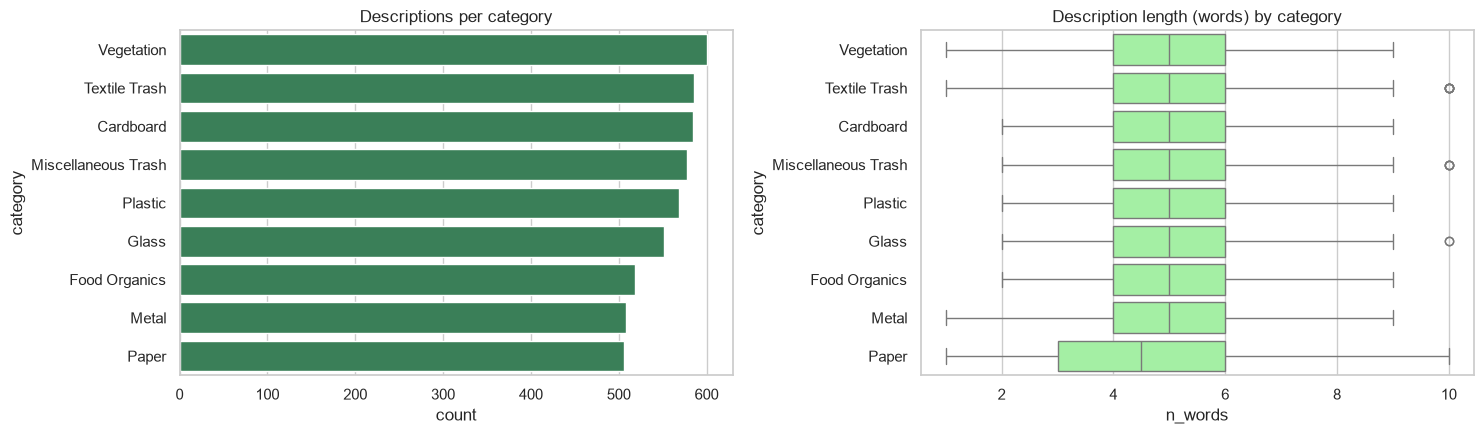

count    5000.00
mean        4.85
std         1.55
min         1.00
25%         4.00
50%         5.00
75%         6.00
max        10.00


In [9]:
# Duplicates and conflicting labels
norm_desc = desc_df["description"].str.lower().str.strip()
n_dup = norm_desc.duplicated().sum()
labels_per_text = desc_df.assign(n=norm_desc).groupby("n")["category"].nunique()
n_conflict = int((labels_per_text > 1).sum())
print(f"Duplicate descriptions (case-insensitive): {n_dup} ({n_dup / len(desc_df):.1%})")
print(f"Descriptions labelled with more than one category: {n_conflict}")
if n_conflict:
    ex = labels_per_text[labels_per_text > 1].index[:5]
    display(desc_df[norm_desc.isin(ex)].sort_values("description")[["description", "category"]])

# Category balance and length by category
desc_df["n_words"] = desc_df["description"].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
order = desc_df["category"].value_counts().index
sns.countplot(data=desc_df, y="category", order=order, ax=axes[0], color="seagreen")
axes[0].set_title("Descriptions per category")
sns.boxplot(data=desc_df, y="category", x="n_words", order=order, ax=axes[1], color="palegreen")
axes[1].set_title("Description length (words) by category")
plt.tight_layout()
plt.show()
print(desc_df["n_words"].describe().round(2).to_string())

In [10]:
# Vocabulary analysis
def simple_tokens(s):
    return re.findall(r"[a-z0-9#]+(?:-[a-z0-9]+)*", str(s).lower())

vocab = Counter(t for s in desc_df["description"] for t in simple_tokens(s))
print(f"Vocabulary size: {len(vocab)} unique tokens | total tokens: {sum(vocab.values())}")
print("Top 20 tokens:", vocab.most_common(20))

# Distinctive words per category: TF-IDF over one 'document' per category
cat_docs = desc_df.groupby("category")["description"].apply(" ".join)
cat_tfidf = TfidfVectorizer(stop_words="english", token_pattern=r"[a-z][a-z\-]+")
M = cat_tfidf.fit_transform(cat_docs.values)
terms = np.array(cat_tfidf.get_feature_names_out())
distinct = {c: ", ".join(terms[np.argsort(-M[i].toarray().ravel())[:10]])
            for i, c in enumerate(cat_docs.index)}
display(pd.DataFrame.from_dict(distinct, orient="index", columns=["Most distinctive words"]))

# Generic modifiers: words that appear in >= 7 of the 9 categories
cats_per_word = defaultdict(set)
for d, c in zip(desc_df["description"], desc_df["category"]):
    for t in set(simple_tokens(d)):
        cats_per_word[t].add(c)
generic = sorted([w for w, cs in cats_per_word.items() if len(cs) >= 7],
                 key=lambda w: -vocab[w])
print(f"\nGeneric words shared by >= 7 categories ({len(generic)}):", generic[:30])

Vocabulary size: 305 unique tokens | total tokens: 24308
Top 20 tokens: [('with', 727), ('glass', 424), ('empty', 348), ('bottle', 342), ('food', 316), ('paper', 316), ('box', 313), ('residue', 309), ('plastic', 251), ('brand', 247), ('metal', 241), ('dry', 211), ('new', 196), ('soiled', 189), ('crumpled', 189), ('medium', 187), ('orange', 186), ('stained', 185), ('intact', 184), ('broken', 184)]


,Most distinctive words
Cardboard,"box, cardboard, packaging, toilet, roll, gift,..."
Food Organics,"peel, shells, scraps, bones, pit, avocado, spo..."
Glass,"glass, bottle, light, bulb, ornament, perfume,..."
Metal,"metal, hanger, wire, steel, tin, foil, aluminu..."
Miscellaneous Trash,"vacuum, disposable, ceramic, rubber, tape, dvd..."
Paper,"paper, notebook, book, paperback, envelope, ne..."
Plastic,"plastic, bottle, wrap, container, clamshell, b..."
Textile Trash,"fabric, cotton, cloth, carpet, linen, wool, sw..."
Vegetation,"plant, trimmings, leaves, tree, clippings, wee..."



Generic words shared by >= 7 categories (84): ['with', 'empty', 'food', 'residue', 'brand', 'dry', 'new', 'soiled', 'crumpled', 'medium', 'orange', 'stained', 'intact', 'broken', 'patterned', 'wrinkled', 'wet', 'torn', 'partial', 'brown', 'filled', 'partially', 'ripped', 'fun-sized', 'travel-sized', 'regular-sized', 'enormous', 'white', 'oversized', 'clean']


In [11]:
# Disposal instructions available per category (used later as RAG documents)
instr = desc_df.groupby("category")["disposal_instruction"].agg(["nunique", lambda s: s.unique()[:3]])
instr.columns = ["n_unique_instructions", "examples"]
display(instr)

,n_unique_instructions,examples
category,,
Cardboard,5,"[If contaminated with food, tear off contamina..."
Food Organics,5,"[If no compost available, place in general was..."
Glass,5,"[Remove caps, lids, and corks before recycling..."
Metal,5,"[For aerosol cans, ensure they are completely ..."
Miscellaneous Trash,5,[Hazardous items like batteries require specia...
Paper,5,[Remove any plastic or metal attachments befor...
Plastic,5,"[Remove labels if possible., Plastic bags can ..."
Textile Trash,5,[Look for textile recycling programs in your a...
Vegetation,5,[Large branches may need to be cut to appropri...


#### Text dataset: observations

Every figure below comes from the run above (5,000 rows x 5 columns).

- **Structure — confirmed.** Descriptions average **4.85 words** (min 1, max 10). The vocabulary is tiny: **305 unique tokens** across 24,308 total tokens. **84 words** appear in 7 or more of the 9 categories (`with`, `empty`, `food`, `residue`, `brand`, `dry`, `soiled`, `crumpled`, `orange`, `stained`, `fun-sized`, `travel-sized`, ...), so roughly a quarter of the vocabulary is non-discriminative and the **object noun carries nearly all the signal**.
- **Two columns are empty.** `common_confusion` and `material_composition` are **100% NaN** across all 5,000 rows. Only `description`, `category` and `disposal_instruction` carry information, so the confusable pairs the schema hints at do not exist in the data — which is why Part 2 has to discover them from the confusion matrix instead.
- **Consequence — confirmed.** Because the corpus is template-generated, a TF-IDF baseline (0.9960) and DistilBERT (1.0000) both saturate the test set. That is **not** evidence the models understand residents, so Part 3 adds a near-duplicate check and a hand-written challenge set.
- **Duplicates and conflicts.** **61 duplicate descriptions (1.2%)** were removed case-insensitively before splitting, taking the corpus from 5,000 to **4,939** rows. No additional conflicting-label rows remained, so all 61 removals were exact duplicates. Splitting afterwards guarantees no phrase appears on both sides of a boundary.
- **Disposal instructions.** Each of the 9 categories carries exactly **5 distinct instructions** (45 in total), reused across rows. These supply the 9 disposal documents in the RAG corpus alongside the 67 policy chunks — **76 chunks** in all.

### 1.5 Explore the Policy Documents

We examine each policy's type, covered categories, effective date and length, and extract its **section headings** (lines ending in `:`). The headings reveal a consistent structure: *Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits*. Part 1.6 uses that structure to chunk documents into meaningful sections instead of arbitrary word windows.

In [12]:
with open("waste_policy_documents.json") as f:
    policies = json.load(f)

policy_df = pd.DataFrame(policies)
policy_df["n_words"] = policy_df["document_text"].str.split().str.len()
policy_df["n_categories"] = policy_df["categories_covered"].apply(len)
print(f"Policy documents: {len(policy_df)} | keys: {list(policies[0].keys())}")
display(policy_df[["policy_id", "policy_type", "categories_covered", "effective_date",
                   "jurisdiction", "n_words"]].sort_values("effective_date"))

heading_counts = Counter(
    line.strip()[:-1] for t in policy_df["document_text"]
    for line in t.splitlines() if line.strip().endswith(":"))
print("\nSection headings across all policies:")
print(pd.Series(heading_counts).sort_values(ascending=False).to_string())

covered = Counter(c for cats in policy_df["categories_covered"] for c in cats)
missing = [c for c in class_names if c not in covered]
print("\nPolicy coverage per image class:", {c: covered.get(c, 0) for c in class_names})
print("Classes with no dedicated policy:", missing or "none")
print("\nExample document:\n", policies[0]["document_text"][:600])

Policy documents: 14 | keys: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


,policy_id,policy_type,categories_covered,effective_date,jurisdiction,n_words
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,Metro City,97
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,Metro City,86
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,Metro City,94
11,12,Commercial Recycling Standards,"[Food Organics, Metal, Miscellaneous Trash]",2023-05-05,Metro City,102
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,Metro City,98
10,11,Residential Recycling Rules,"[Plastic, Metal, Glass, Miscellaneous Trash, V...",2023-05-26,Metro City,146
12,13,Multi-Unit Building Guidelines,"[Cardboard, Glass, Textile Trash]",2023-07-04,Metro City,100
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,Metro City,102
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,Metro City,100
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,Metro City,95



Section headings across all policies:
Benefits                          9
Acceptable Items                  8
Non-Acceptable Items              8
Collection Method                 8
Preparation Instructions          8
GENERAL REQUIREMENTS              5
METAL GUIDELINES                  3
VEGETATION GUIDELINES             3
MISCELLANEOUS TRASH GUIDELINES    3
GLASS GUIDELINES                  2
CARDBOARD GUIDELINES              2
TEXTILE TRASH GUIDELINES          2
PLASTIC GUIDELINES                2
Waste Reduction Tips              1
Special Handling Items            1
Items That Cannot Be Recycled     1
FOOD ORGANICS GUIDELINES          1

Policy coverage per image class: {'Cardboard': 3, 'Food Organics': 2, 'Glass': 3, 'Metal': 4, 'Miscellaneous Trash': 4, 'Paper': 1, 'Plastic': 3, 'Textile Trash': 3, 'Vegetation': 4}
Classes with no dedicated policy: none

Example document:
 TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and li

#### Policy documents: observations

- The documents are short, formal and consistently structured, using headings followed by bullet lists. Section-level chunks are therefore natural retrieval units: a question about *how to prepare* an item should retrieve the *Preparation Instructions* section.
- Some policies may cover several categories, or none of the image classes (for example penalties or general rules). These are tagged as **General** so they can be retrieved for any category.
- Classes without a dedicated policy rely on the resident disposal instructions from the CSV. This is another reason to add those instructions to the corpus.
- The small corpus limits what a generator can say, but it makes factual grounding easy to verify.

### 1.6 Data Pipelines and Splits

#### 1.6.1 Image pipeline: stratified 70 / 15 / 15 split on file paths

The original notebook carved the test set out of the validation set with `take()` and `skip()`. That approach is unsafe because `image_dataset_from_directory` **reshuffles on every pass**. The same image can land in both validation and test, and labels collected in a separate loop no longer line up with the predictions.

We instead split the **file paths** with `train_test_split(stratify=...)`, which:

- preserves the class proportions in every split;
- fixes each split permanently, so there is no overlap between them;
- lets us keep the test file paths for Part 5, where the brief asks us to test with a test-set image.

**Preprocessing:** decode the image, force 3 channels (some PNGs have an alpha channel), and resize to 224×224. **Pixels stay in the 0–255 range**, because Keras' EfficientNetB0 contains its own rescaling and normalisation layers. Dividing by 255 beforehand, as the original notebook did, feeds the network near-black images, which is why that model never learned. Only the training set is shuffled; validation and test keep a fixed order so predictions align with labels.

In [13]:
all_paths = clean_meta["path"].tolist()
all_labels = clean_meta["category"].map({c: i for i, c in enumerate(class_names)}).tolist()

train_p, temp_p, train_y, temp_y = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

assert not (set(train_p) & set(val_p) or set(train_p) & set(test_p) or set(val_p) & set(test_p))

split_table = pd.DataFrame({
    "train": pd.Series(train_y).map(dict(enumerate(class_names))).value_counts(),
    "val": pd.Series(val_y).map(dict(enumerate(class_names))).value_counts(),
    "test": pd.Series(test_y).map(dict(enumerate(class_names))).value_counts(),
}).loc[class_names]
split_table.loc["TOTAL"] = split_table.sum()
display(split_table)

def load_image(path, label):
    """Read -> decode (3 channels) -> resize. Output float32 in [0, 255]."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img.set_shape((*IMG_SIZE, 3))
    return img, label

def make_image_ds(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_image_ds(train_p, train_y, training=True)
val_ds = make_image_ds(val_p, val_y, training=False)
test_ds = make_image_ds(test_p, test_y, training=False)

xb, yb = next(iter(train_ds))
print("Batch shape:", xb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))

,train,val,test
Cardboard,323,69,69
Food Organics,288,61,62
Glass,294,63,63
Metal,553,119,118
Miscellaneous Trash,346,74,75
Paper,350,75,75
Plastic,645,138,138
Textile Trash,222,48,48
Vegetation,305,66,65
TOTAL,3326,713,713


Batch shape: (32, 224, 224, 3) | pixel range: 0.0 - 255.0


#### 1.6.2 Text pipeline: normalisation, de-duplication, stratified 70 / 15 / 15 split

The normalisation is deliberately **light**, because DistilBERT's WordPiece tokenizer is trained on natural text:

- Unicode NFKC normalisation, lowercasing and whitespace collapsing;
- **keep** digits, `#`, hyphens and `/`, so resin codes such as "#1 PET" and compounds such as "fun-sized" survive (the original cleaning deleted them);
- drop exact duplicates and conflicting labels **before** splitting, so no phrase appears in both train and test.

A separate validation set is used for model selection, so the test set is touched only once, for the final evaluation.

In [14]:
def normalize_text(t):
    t = unicodedata.normalize("NFKC", str(t)).lower()
    t = re.sub(r"[^\w\s#\-/%.]", " ", t)      # remove odd symbols, keep resin codes & hyphens
    t = re.sub(r"\s+", " ", t).strip()
    return t

text_df = desc_df.copy()
text_df["text"] = text_df["description"].map(normalize_text)
conflicting = text_df.groupby("text")["category"].transform("nunique") > 1
before = len(text_df)
text_df = text_df[~conflicting].drop_duplicates("text").reset_index(drop=True)
print(f"Rows: {before} -> {len(text_df)} after removing duplicates/conflicts")

text_label_names = sorted(text_df["category"].unique())
if set(text_label_names) != set(class_names):
    print("WARNING: text categories differ from image classes:",
          set(text_label_names) ^ set(class_names))
label2id = {c: i for i, c in enumerate(text_label_names)}
id2label = {i: c for c, i in label2id.items()}
text_df["label"] = text_df["category"].map(label2id)

train_df_text, temp_df = train_test_split(text_df, test_size=0.30,
                                          stratify=text_df["category"], random_state=SEED)
val_df_text, test_df_text = train_test_split(temp_df, test_size=0.50,
                                             stratify=temp_df["category"], random_state=SEED)
X_train_text, y_train_text = train_df_text["text"].tolist(), train_df_text["label"].values
X_val_text, y_val_text = val_df_text["text"].tolist(), val_df_text["label"].values
X_test_text, y_test_text = test_df_text["text"].tolist(), test_df_text["label"].values

assert not set(X_train_text) & set(X_test_text), "train/test overlap"
print(f"Train {len(X_train_text)} | Val {len(X_val_text)} | Test {len(X_test_text)}")
print("Example:", desc_df['description'].iloc[4], "->", normalize_text(desc_df['description'].iloc[4]))

Rows: 5000 -> 4939 after removing duplicates/conflicts
Train 3457 | Val 741 | Test 741
Example: empty fun-sized purple apple core -> empty fun-sized purple apple core


#### 1.6.3 RAG document preparation: section-aware chunking plus disposal instructions

The original 200-word chunking produced exactly one chunk per document, so nothing was actually chunked. We now:

1. **Split each policy on its blank-line-separated sections.** Each section becomes one chunk, prefixed with the document title for context. Bullets are joined into a single sentence ("Preparation Instructions: rinse containers; remove caps; ..."). Any section longer than 120 words is split into overlapping windows.
2. **Tag every chunk with all categories it covers**, not just the first one. Policies covering none of the image classes are tagged **General**.
3. **Add one "Resident disposal instructions" chunk per category**, built from the CSV's `disposal_instruction` column, as the brief requires.

Each chunk stores metadata (source, section, effective date, categories), which enables category filtering and source citation.

In [15]:
CATEGORY_SET = set(class_names)
CATEGORY_LOOKUP = {c.lower(): c for c in class_names}

def block_to_section(block):
    """Turn 'Heading:\n- a\n- b' into ('Heading', 'Heading: a; b.')."""
    lines = [l.strip() for l in block.splitlines() if l.strip()]
    head, items = lines[0], lines[1:]
    if head.endswith(":") and items:
        items = [re.sub(r"^[-\u2022*]\s*", "", l) for l in items]
        body = f"{head} " + "; ".join(i.rstrip(".;") for i in items) + "."
        return head[:-1].strip(), body
    return "Overview", " ".join(lines)

def window_words(text, size=120, overlap=20):
    words = text.split()
    if len(words) <= size:
        return [text]
    step = size - overlap
    return [" ".join(words[i:i + size]) for i in range(0, len(words) - overlap, step)]

rag_chunks = []
for p in policies:
    cats = [CATEGORY_LOOKUP[c.lower()] for c in p.get("categories_covered", [])
            if c.lower() in CATEGORY_LOOKUP] or ["General"]
    blocks = [b.strip() for b in re.split(r"\n\s*\n", p.get("document_text", "")) if b.strip()]
    if not blocks:
        continue
    title = blocks[0].splitlines()[0].strip()
    first_rest = "\n".join(blocks[0].splitlines()[1:]).strip()
    blocks = ([first_rest] if first_rest else []) + blocks[1:]
    for block in blocks:
        section, body = block_to_section(block)
        for piece in window_words(body):
            rag_chunks.append(dict(
                id=len(rag_chunks), doc_type="policy", policy_id=p.get("policy_id"),
                source=p.get("policy_type", title), title=title, section=section,
                body=piece, text=f"{title} - {piece}", categories=cats,
                effective_date=p.get("effective_date", "")))

for c in class_names:
    uniq = desc_df.loc[desc_df["category"] == c, "disposal_instruction"].dropna().unique()
    if len(uniq) == 0:
        continue
    body = f"Resident disposal instructions for {c}: " + " ".join(
        u.strip().rstrip(".") + "." for u in uniq)
    for piece in window_words(body):
        rag_chunks.append(dict(
            id=len(rag_chunks), doc_type="disposal", policy_id=None,
            source=f"{c} Resident Disposal Instructions", title=f"{c} disposal instructions",
            section="Resident disposal instructions", body=piece, text=piece,
            categories=[c], effective_date=""))

chunk_df = pd.DataFrame(rag_chunks)
print(f"RAG chunks: {len(rag_chunks)} "
      f"(policy: {(chunk_df.doc_type == 'policy').sum()}, disposal: {(chunk_df.doc_type == 'disposal').sum()})")
cat_chunk_counts = Counter(c for cs in chunk_df["categories"] for c in cs)
print("Chunks per category:", dict(cat_chunk_counts))
display(chunk_df[["source", "section", "categories", "body"]].head(8))

RAG chunks: 76 (policy: 67, disposal: 9)
Chunks per category: {'Textile Trash': 15, 'Glass': 16, 'Food Organics': 10, 'Plastic': 16, 'Vegetation': 21, 'Cardboard': 15, 'Metal': 21, 'Paper': 6, 'Miscellaneous Trash': 19}


,source,section,categories,body
0,Textile Trash Recycling Guidelines,Acceptable Items,[Textile Trash],Acceptable Items: Clean clothing (all conditio...
1,Textile Trash Recycling Guidelines,Non-Acceptable Items,[Textile Trash],Non-Acceptable Items: Wet or moldy textiles; H...
2,Textile Trash Recycling Guidelines,Collection Method,[Textile Trash],Collection Method: Place items in dedicated te...
3,Textile Trash Recycling Guidelines,Preparation Instructions,[Textile Trash],Preparation Instructions: Ensure all items are...
4,Textile Trash Recycling Guidelines,Benefits,[Textile Trash],Benefits: Textile recycling conserves resource...
5,Glass Recycling Guidelines,Acceptable Items,[Glass],Acceptable Items: Glass bottles (all colors); ...
6,Glass Recycling Guidelines,Non-Acceptable Items,[Glass],Non-Acceptable Items: Window glass or mirrors;...
7,Glass Recycling Guidelines,Collection Method,[Glass],Collection Method: Place in dedicated glass re...


## Part 2: Waste Material Classification with CNN

### 2.1 Data Augmentation

Augmentation creates realistic variations of the training images: flips, rotations, zooms and contrast changes that mimic how residents photograph items. It works as a regulariser, so the model cannot memorise exact pixels.

The augmentation layers sit **inside the model**. Keras applies them only during training and turns them off automatically for validation, testing and inference. The original notebook defined an augmentation pipeline but never used it.

The cell below shows six augmented versions of one training image.

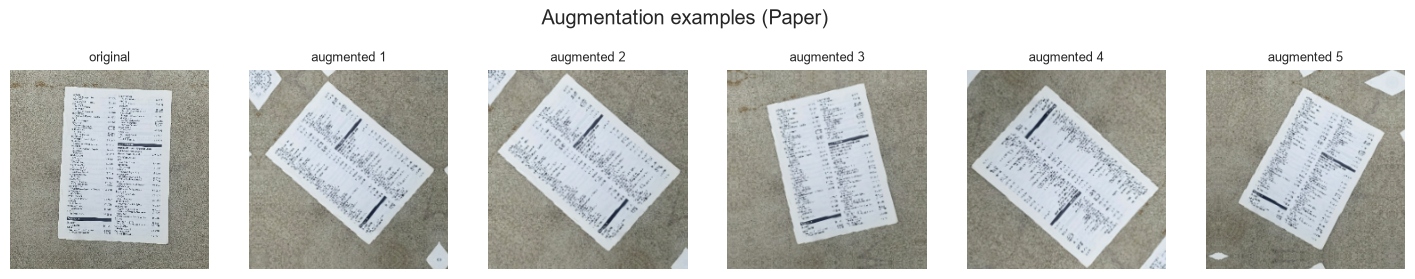

In [16]:
def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ], name="augmentation")

demo_aug = make_augmentation()
sample_img, sample_lbl = load_image(tf.constant(train_p[0]), train_y[0])
fig, axes = plt.subplots(1, 6, figsize=(18, 3.3))
for i, ax in enumerate(axes):
    out = sample_img if i == 0 else demo_aug(sample_img[None], training=True)[0]
    ax.imshow(np.clip(out.numpy() / 255.0, 0, 1))
    ax.set_title("original" if i == 0 else f"augmented {i}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Augmentation examples ({class_names[sample_lbl]})")
plt.show()

### 2.2 Handling Class Imbalance: Class Weights

`compute_class_weight("balanced")` gives each class a weight inversely proportional to its frequency in the **training** split. In the loss function, a mistake on a rare class such as Textile Trash then costs more than a mistake on Plastic. This counteracts the pull toward majority classes without discarding or duplicating any data.

In [17]:
cw = compute_class_weight("balanced", classes=np.arange(len(class_names)), y=np.array(train_y))
class_weight = dict(enumerate(cw))
display(pd.DataFrame({"train images": split_table.loc[class_names, "train"].values,
                      "class weight": np.round(cw, 3)}, index=class_names))

,train images,class weight
Cardboard,323,1.144
Food Organics,288,1.283
Glass,294,1.257
Metal,553,0.668
Miscellaneous Trash,346,1.068
Paper,350,1.056
Plastic,645,0.573
Textile Trash,222,1.665
Vegetation,305,1.212


### 2.3 Model Builder: Transfer Learning with a Configurable Head

**Base model choice.** EfficientNetB0 is the primary candidate. It reaches strong ImageNet accuracy with only about 4M parameters, using compound scaling of depth, width and resolution. That size suits a CPU training budget and a lightweight assistant that could run on a phone. MobileNetV2 is included as a comparison because it is the standard mobile-first alternative.

**Preprocessing per base model.** This is the key fix from the original notebook:

- **EfficientNetB0** includes its own `Rescaling` and `Normalization` layers, so it receives raw 0–255 pixels.
- **MobileNetV2** expects inputs in [-1, 1], so we add `Rescaling(1/127.5, offset=-1)`.

**Head.** Global average pooling → Dropout → Dense(ReLU, L2 penalty) → [optional second Dense] → Dropout → Softmax over 9 classes. Dropout and L2 are the regularisers the brief asks for. `dense_units` and `extra_dense` control the width and depth of the custom layers.

**Loss and metric.** Sparse categorical cross-entropy, because labels are integers, with accuracy tracked during training. Macro-F1 is reported at evaluation because it weights every class equally.

The base model is called with `training=False`, so its BatchNorm layers stay in inference mode even when we unfreeze layers later. This prevents fine-tuning from corrupting the ImageNet statistics.

In [18]:
def build_cnn(base_name="efficientnetb0", dense_units=256, dropout=0.3, l2=1e-4,
              extra_dense=0, lr=1e-3):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_augmentation()(inputs)
    if base_name == "efficientnetb0":
        base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                                 input_shape=(*IMG_SIZE, 3))
        # EfficientNet rescales internally -> feed raw 0-255 pixels
    elif base_name == "mobilenetv2":
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet",
                                              input_shape=(*IMG_SIZE, 3))
        x = layers.Rescaling(1 / 127.5, offset=-1, name="to_minus1_1")(x)
    else:
        raise ValueError(base_name)
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    if extra_dense:
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(extra_dense, activation="relu",
                         kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(len(class_names), activation="softmax", name="class_probs")(x)
    model = keras.Model(inputs, outputs, name=f"{base_name}_head{dense_units}")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model, base

### 2.4 Architecture and Hyperparameter Experiments

We compare four configurations with a frozen base for `EXP_EPOCHS` epochs each. The experiments vary:

- **width** (256 vs. 512 units),
- **depth** (one vs. two dense layers),
- **regularisation strength** (dropout 0.3 vs. 0.5),
- **base model** (EfficientNetB0 vs. MobileNetV2).

The selection criterion is **best validation accuracy**. The test set is never used for choosing. We also record the train–validation gap as an overfitting indicator.

In [19]:
cnn_experiments = [
    dict(name="EffB0 | 256 | drop 0.3", base_name="efficientnetb0", dense_units=256, dropout=0.3),
    dict(name="EffB0 | 512 | drop 0.5", base_name="efficientnetb0", dense_units=512, dropout=0.5),
    dict(name="EffB0 | 256+128 | drop 0.3", base_name="efficientnetb0", dense_units=256,
         dropout=0.3, extra_dense=128),
    dict(name="MobileNetV2 | 256 | drop 0.3", base_name="mobilenetv2", dense_units=256, dropout=0.3),
]

exp_rows = []
for cfg in cnn_experiments:
    keras.backend.clear_session()
    set_seeds()
    params = {k: v for k, v in cfg.items() if k != "name"}
    m, _ = build_cnn(**params)
    t0 = time.time()
    h = m.fit(train_ds, validation_data=val_ds, epochs=EXP_EPOCHS,
              class_weight=class_weight, verbose=1)
    best_ep = int(np.argmax(h.history["val_accuracy"]))
    exp_rows.append({
        "config": cfg["name"],
        "best_val_acc": h.history["val_accuracy"][best_ep],
        "train_acc_at_best": h.history["accuracy"][best_ep],
        "gap (train-val)": h.history["accuracy"][best_ep] - h.history["val_accuracy"][best_ep],
        "trainable_params": int(sum(np.prod(w.shape) for w in m.trainable_weights)),
        "minutes": (time.time() - t0) / 60,
    })
    del m
    gc.collect()

cnn_exp_df = pd.DataFrame(exp_rows).sort_values("best_val_acc", ascending=False).round(4)
display(cnn_exp_df)
best_cnn_cfg = next(c for c in cnn_experiments if c["name"] == cnn_exp_df.iloc[0]["config"])
print("Selected configuration:", best_cnn_cfg["name"])

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6182 - loss: 1.0987 - val_accuracy: 0.7728 - val_loss: 0.7174
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.7640 - loss: 0.6757 - val_accuracy: 0.7938 - val_loss: 0.6421
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.7971 - loss: 0.5970 - val_accuracy: 0.8022 - val_loss: 0.5794
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8070 - loss: 0.5436 - val_accuracy: 0.8331 - val_loss: 0.5100
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8250 - loss: 0.5013 - val_accuracy: 0.8289 - val_loss: 0.5489
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.5661 - loss: 1.2639 - val_accuracy: 0.7602 - val_loss: 0.7967
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6990 - loss: 0.8732 - val_accuracy: 0.8079 - val_loss: 0.6379
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.7456 - loss: 0.7544 - val_accuracy: 0.

,config,best_val_acc,train_acc_at_best,gap (train-val),trainable_params,minutes
0,EffB0 | 256 | drop 0.3,0.8331,0.8070,-0.0261,330249,14.9964
1,EffB0 | 512 | drop 0.5,0.8275,0.7832,-0.0443,660489,14.8338
2,EffB0 | 256+128 | drop 0.3,0.8233,0.7520,-0.0713,361993,12.9876
3,MobileNetV2 | 256 | drop 0.3,0.7686,0.7405,-0.0281,330249,9.3174


Selected configuration: EffB0 | 256 | drop 0.3


### 2.5 Train the Selected Head

We rebuild the winning configuration and train it longer, with two callbacks:

- **EarlyStopping** on validation loss (patience 4, restores the best weights), which stops training once the model begins to overfit;
- **ReduceLROnPlateau** (halves the learning rate after 2 stagnant epochs), which lets the optimiser settle into a minimum.

In [20]:
keras.backend.clear_session()
set_seeds()
cnn_model, cnn_base = build_cnn(**{k: v for k, v in best_cnn_cfg.items() if k != "name"})
cnn_model.summary(line_length=100)

head_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6),
]
hist_head = cnn_model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
                          class_weight=class_weight, callbacks=head_callbacks)
val_acc_head = cnn_model.evaluate(val_ds, verbose=0)[1]
print(f"Validation accuracy after head training: {val_acc_head:.4f}")

Model: "efficientnetb0_head256"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                         │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ augmentation (Sequential)                  │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetb0 (Functional)                │ (None, 7, 7, 1280)              │         4,049,571 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 1280)                    │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 1280)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 256)                     │           327,936 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ class_probs (Dense)                        │ (None, 9)                       │             2,313 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 4,379,820 (16.71 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.6049 - loss: 1.1124 - val_accuracy: 0.7630 - val_loss: 0.7181 - learning_rate: 0.0010
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7652 - loss: 0.6749 - val_accuracy: 0.7770 - val_loss: 0.6364 - learning_rate: 0.0010
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7874 - loss: 0.5928 - val_accuracy: 0.8163 - val_loss: 0.5694 - learning_rate: 0.0010
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.8226 - loss: 0.5218 - val_accuracy: 0.8247 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8337 - loss: 0.4838 - val_accuracy: 0.8261 - val_loss: 0.5579 - learning_rate: 0.0010
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8503 - loss: 0.4480 - val_accuracy: 0.8303 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8527 - loss: 0.

### 2.6 Fine-tune the Top of the Base Model

Next we unfreeze the top `FINE_TUNE_LAYERS` layers of the base model, so the highest-level filters can adapt from ImageNet objects to waste materials. Three safeguards protect the pretrained weights:

- a **very low learning rate** (1e-5);
- **BatchNorm layers kept frozen**;
- **early stopping** on validation loss.

The model must be recompiled after changing `trainable` flags for the change to take effect. We keep fine-tuning only if it improves validation accuracy; otherwise we restore the head-only weights.

In [21]:
head_weights = cnn_model.get_weights()

cnn_base.trainable = True
for layer in cnn_base.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in cnn_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
print("Trainable layers in base:", sum(l.trainable for l in cnn_base.layers))

cnn_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
n_head = len(hist_head.history["loss"])
hist_ft = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=n_head + FT_EPOCHS, initial_epoch=n_head,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-7)])

val_acc_ft = cnn_model.evaluate(val_ds, verbose=0)[1]
print(f"Validation accuracy: head-only {val_acc_head:.4f} -> fine-tuned {val_acc_ft:.4f}")
if val_acc_ft < val_acc_head:
    cnn_model.set_weights(head_weights)
    print("Fine-tuning did not help on validation -> restored head-only weights.")

Trainable layers in base: 32
Epoch 21/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.9369 - loss: 0.2399 - val_accuracy: 0.8724 - val_loss: 0.4272 - learning_rate: 1.0000e-05
Epoch 22/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.9423 - loss: 0.2257 - val_accuracy: 0.8724 - val_loss: 0.4274 - learning_rate: 1.0000e-05
Epoch 23/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9381 - loss: 0.2348 - val_accuracy: 0.8738 - val_loss: 0.4216 - learning_rate: 1.0000e-05
Epoch 24/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9402 - loss: 0.2301 - val_accuracy: 0.8738 - val_loss: 0.4221 - learning_rate: 1.0000e-05
Epoch 25/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9390 - loss: 0.2331 - val_accuracy: 0.8752 - val_loss: 0.4144 - learning_rate: 1.0000e-05
Epoch 26/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9390 - loss: 0.2253 - val_accuracy: 0.8766 - val_loss: 0.4161 - learning_rate: 1.0000e-05
Epoch 27/30
104/104 ━━━

### 2.7 Learning Curves

These curves show the training and validation accuracy and loss across both phases. The dashed line marks where fine-tuning began.

- If validation loss rises while training loss falls, the model is overfitting.
- If both curves are flat, the model is underfitting. This is what the original notebook's curves looked like.

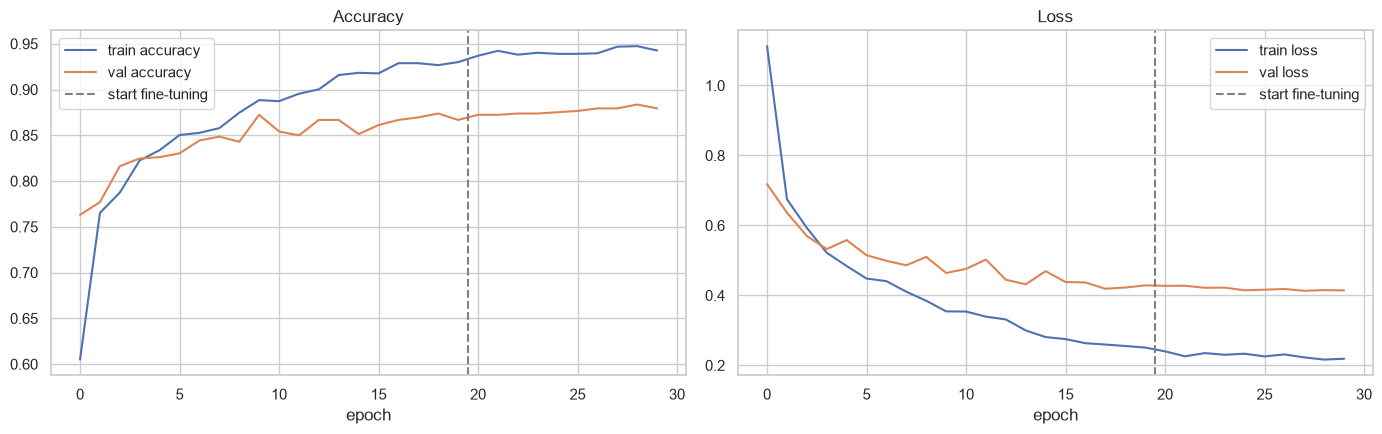

In [22]:
def merge_hist(*hs):
    out = defaultdict(list)
    for h in hs:
        for k, v in h.history.items():
            out[k].extend(v)
    return out

H = merge_hist(hist_head, hist_ft)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, key in zip(axes, ["accuracy", "loss"]):
    ax.plot(H[key], label=f"train {key}")
    ax.plot(H[f"val_{key}"], label=f"val {key}")
    ax.axvline(n_head - 0.5, ls="--", c="gray", label="start fine-tuning")
    ax.set_xlabel("epoch")
    ax.set_title(key.capitalize())
    ax.legend()
plt.tight_layout()
plt.show()

### 2.8 Test-set Evaluation

We collect **labels and predictions in the same loop**, so they are guaranteed to align. We report:

- accuracy and macro-F1;
- the per-class classification report;
- the confusion matrix, both as raw counts and row-normalised (recall per class).

CNN test accuracy: 0.8808 | macro-F1: 0.8865

                     precision    recall  f1-score   support

          Cardboard      0.802     0.942     0.867        69
      Food Organics      0.948     0.887     0.917        62
              Glass      0.794     0.857     0.824        63
              Metal      0.871     0.915     0.893       118
Miscellaneous Trash      0.922     0.787     0.849        75
              Paper      0.985     0.867     0.922        75
            Plastic      0.866     0.797     0.830       138
      Textile Trash      0.842     1.000     0.914        48
         Vegetation      0.941     0.985     0.962        65

           accuracy                          0.881       713
          macro avg      0.886     0.893     0.886       713
       weighted avg      0.885     0.881     0.880       713



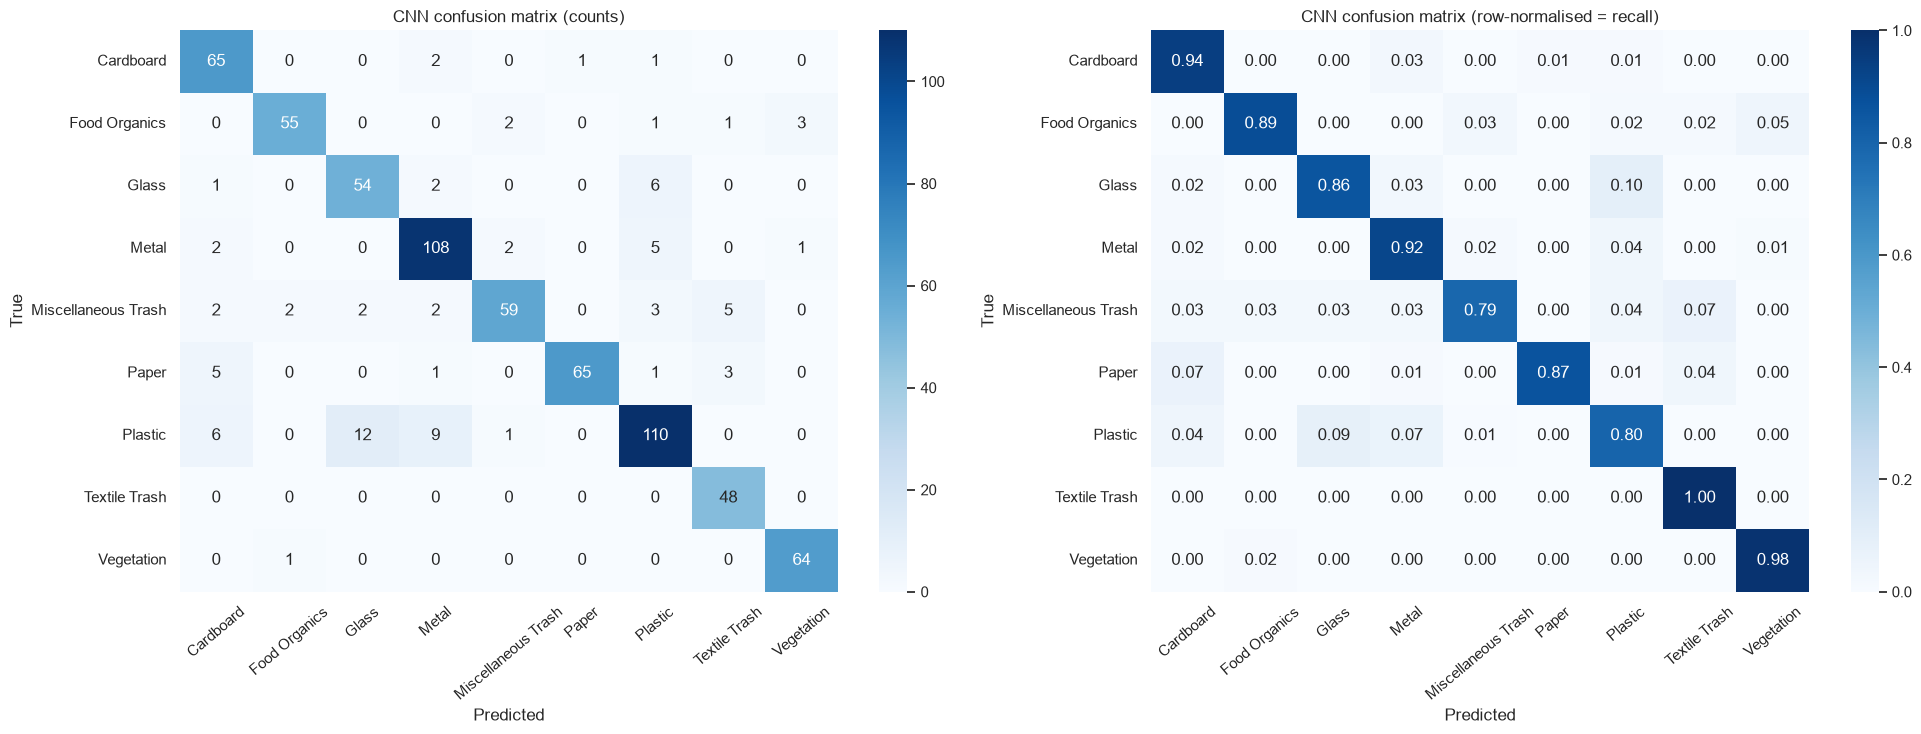

In [23]:
def predict_dataset(model, ds):
    y_true, y_prob = [], []
    for x, y in ds:
        y_prob.append(model.predict(x, verbose=0))
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_prob)

y_true_cnn, y_prob_cnn = predict_dataset(cnn_model, test_ds)
y_pred_cnn = y_prob_cnn.argmax(1)
cnn_test_acc = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_test_f1 = f1_score(y_true_cnn, y_pred_cnn, average="macro")
print(f"CNN test accuracy: {cnn_test_acc:.4f} | macro-F1: {cnn_test_f1:.4f}\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, digits=3))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_norm = cm_cnn / cm_cnn.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title("CNN confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title("CNN confusion matrix (row-normalised = recall)")
for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

### 2.9 Error Pattern Analysis

We analyse the errors from four angles:

1. **Most-confused class pairs:** which specific mistakes the model makes.
2. **Per-class F1 vs. training-set size:** whether errors come from data scarcity (imbalance) or from visual similarity.
3. **Misclassified examples:** what the hard images actually look like.
4. **Confidence vs. correctness:** whether the model knows when it is unsure. This is used in Part 5 to warn users when a prediction is uncertain.

Most frequent confusions:


,true,predicted,count,share_of_true_class
25,Plastic,Glass,12,0.087
26,Plastic,Metal,9,0.065
24,Plastic,Cardboard,6,0.043
9,Glass,Plastic,6,0.095
12,Metal,Plastic,5,0.042
19,Miscellaneous Trash,Textile Trash,5,0.067
20,Paper,Cardboard,5,0.067
23,Paper,Textile Trash,3,0.040


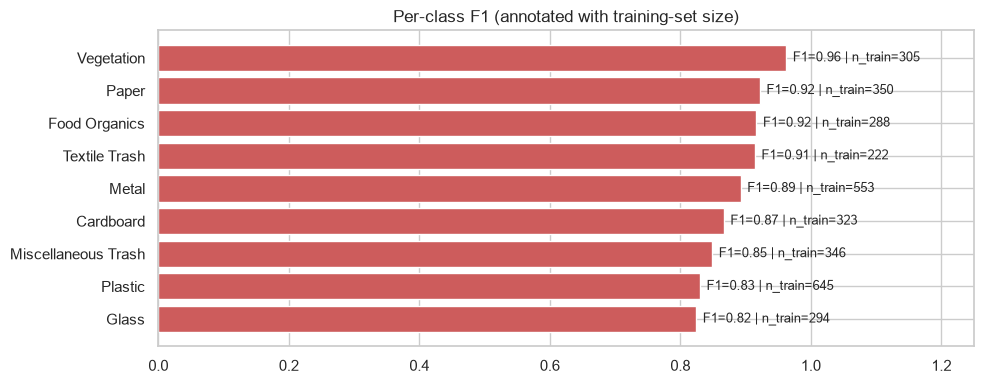

Correlation between class size and F1: -0.39


In [24]:
pairs = [(class_names[i], class_names[j], int(cm_cnn[i, j]), cm_cnn[i, j] / cm_cnn[i].sum())
         for i in range(len(class_names)) for j in range(len(class_names))
         if i != j and cm_cnn[i, j] > 0]
pairs_df = pd.DataFrame(pairs, columns=["true", "predicted", "count", "share_of_true_class"])
print("Most frequent confusions:")
display(pairs_df.sort_values("count", ascending=False).head(8).round(3))

per_class_f1 = f1_score(y_true_cnn, y_pred_cnn, average=None)
pc = pd.DataFrame({"F1": per_class_f1, "train_images": split_table.loc[class_names, "train"].values},
                  index=class_names).sort_values("F1")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(pc.index, pc["F1"], color="indianred")
for i, (f, n) in enumerate(zip(pc["F1"], pc["train_images"])):
    ax.text(f + 0.01, i, f"F1={f:.2f} | n_train={n}", va="center", fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_title("Per-class F1 (annotated with training-set size)")
plt.tight_layout()
plt.show()
print(f"Correlation between class size and F1: {np.corrcoef(pc['F1'], pc['train_images'])[0, 1]:.2f}")

Misclassified test images: 85 / 713


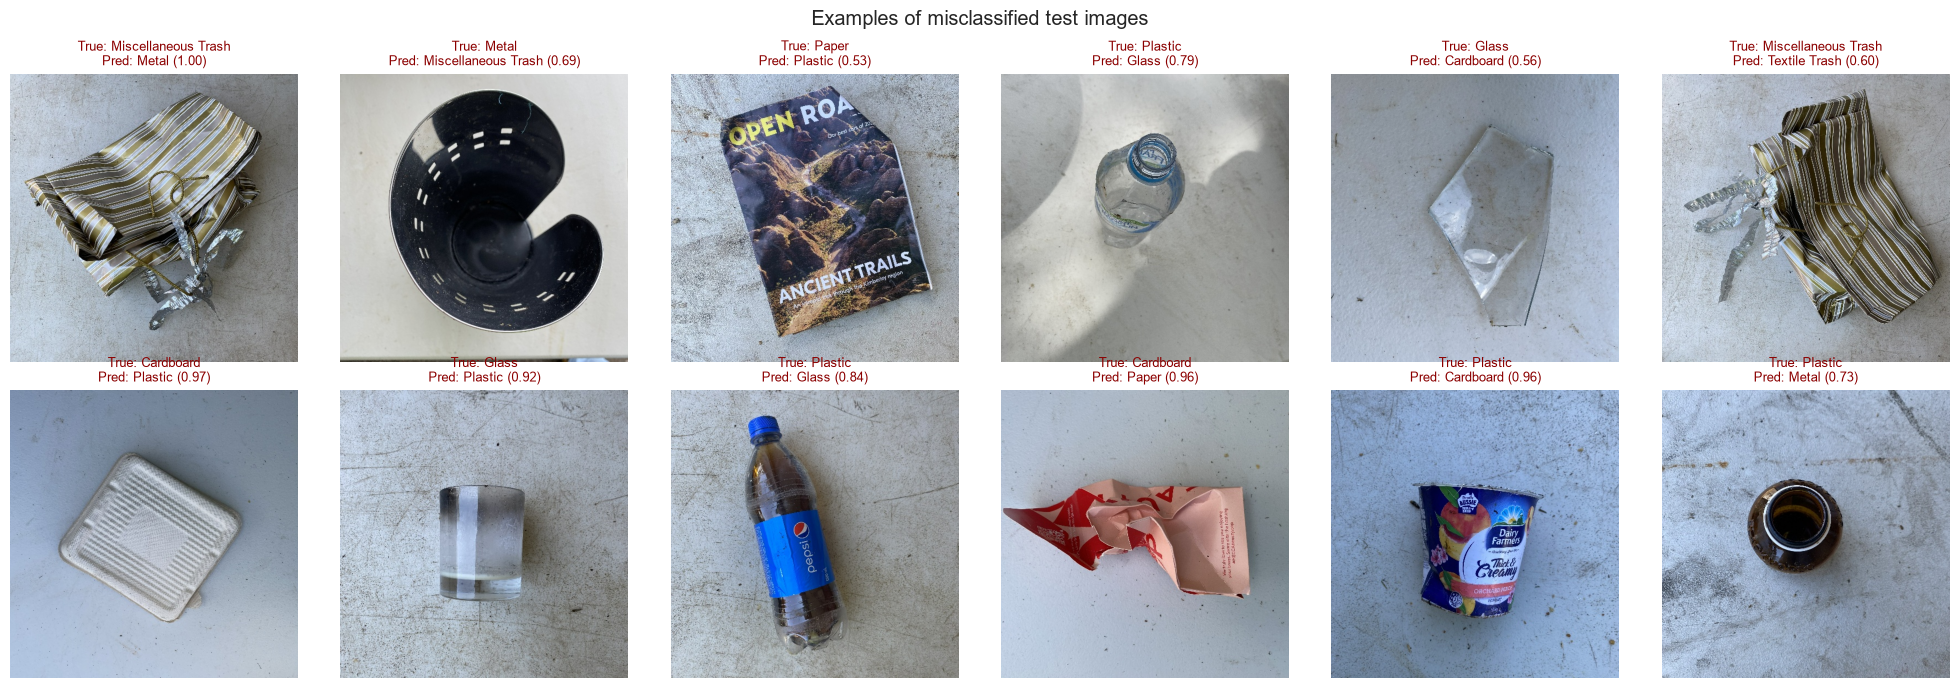

Mean confidence when correct: 0.935 | when wrong: 0.747


,threshold,coverage,accuracy_on_kept
0,0.3,1.000,0.881
1,0.4,0.992,0.884
2,0.5,0.973,0.886
3,0.6,0.934,0.905
4,0.7,0.885,0.913
5,0.8,0.829,0.934
6,0.9,0.734,0.966


Confidence threshold used by the assistant for image warnings: 0.6


In [25]:
wrong = np.where(y_pred_cnn != y_true_cnn)[0]
print(f"Misclassified test images: {len(wrong)} / {len(y_true_cnn)}")
show = np.random.RandomState(SEED).choice(wrong, size=min(12, len(wrong)), replace=False) if len(wrong) else []
if len(show):
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), show):
        with Image.open(test_p[i]) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"True: {class_names[y_true_cnn[i]]}\nPred: {class_names[y_pred_cnn[i]]} "
                     f"({y_prob_cnn[i].max():.2f})", fontsize=9, color="darkred")
    plt.suptitle("Examples of misclassified test images")
    plt.tight_layout()
    plt.show()

# Confidence analysis: accuracy and coverage above each threshold
conf = y_prob_cnn.max(1)
correct = y_pred_cnn == y_true_cnn
print(f"Mean confidence when correct: {conf[correct].mean():.3f} | when wrong: {conf[~correct].mean():.3f}")
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    keep = conf >= t
    rows.append({"threshold": t, "coverage": keep.mean(),
                 "accuracy_on_kept": correct[keep].mean() if keep.any() else np.nan})
thr_df = pd.DataFrame(rows).round(3)
display(thr_df)
ok_thr = thr_df[thr_df["accuracy_on_kept"] >= 0.90]
CNN_CONF_THRESHOLD = float(ok_thr["threshold"].min()) if len(ok_thr) else 0.5
print(f"Confidence threshold used by the assistant for image warnings: {CNN_CONF_THRESHOLD}")

#### CNN: interpretation

All figures from 2.4-2.9, on 3,326 train / 713 val / 713 test images.

- **Model selection.** **EffB0 | 256 units | dropout 0.3** won the 5-epoch screen at **best validation accuracy 0.8331** (11.47 min). It also had the smallest train-validation gap of the three EfficientNet heads (**-0.0261**, against -0.0443 and -0.0713).
- **More head capacity did not help.** The wider 512-unit head scored **0.8275** and the deeper 256+128 head **0.8233**, both below the winner, with gaps widening to -0.0443 and -0.0713. With only 3,326 training images the extra capacity did not buy generalisation. The gaps are negative because train accuracy is measured *with augmentation and dropout active* over just 5 epochs, so the model is still underfit at this stage rather than overfit.
- **EfficientNetB0 clearly beat MobileNetV2:** **0.8331 vs 0.7686**, a 0.0645 gap, for 2 extra minutes per screen (11.47 vs 9.42). The accuracy is worth the cost.
- **Fine-tuning helped, modestly.** Training the head for 20 epochs reached **0.8696** validation accuracy; unfreezing the top of the base model for 10 further epochs with frozen BatchNorm lifted it to **0.8794** (**+0.0098**). The selected model has 4,379,820 parameters, of which **330,249 (1.26 MB, 7.5%)** are trainable at the head stage.
- **Test performance: 0.8808 accuracy, 0.8865 macro-F1** (precision 0.886, recall 0.893). Macro-F1 exceeding accuracy is the class weighting working — the small classes are no longer sacrificed.
- **Challenging categories — one expectation wrong.** The dominant confusion is **Plastic**, not the predicted pairs: Plastic->Glass 12 images (8.7% of Plastic), Plastic->Metal 9 (6.5%), Plastic->Cardboard 6 (4.3%). Glass->Plastic accounts for 9.5% of Glass and Metal->Plastic 4.2%. Paper vs Cardboard is real (5 images, 6.7% of Paper). **Food Organics vs Vegetation never appears in the top eight confusions**, so that organic pair was learned cleanly — vegetation is green and outdoors, food waste is packaged.
- **Imbalance reduced but not removed.** The correlation between class size and F1 is **-0.39**, a moderate negative relationship: weighting stopped the collapse but did not make performance size-independent. Plastic is both the largest class (645 train images) *and* the most frequently misclassified, so visual ambiguity with glass and metal containers matters more than size alone.
- **Confidence is informative.** **85 of 713** test images are misclassified (11.9%). Mean confidence is **0.935 when correct** versus **0.747 when wrong** — a clear 0.19 separation. Raising the threshold trades coverage for accuracy as expected: 0.6 -> 93.4% coverage at 0.905 accuracy, 0.8 -> 82.9% at 0.934, 0.9 -> 73.4% at 0.966. The assistant uses **0.6**, a deliberately coverage-first choice.
- **Honest caveat about that threshold.** In the end-to-end sample the two wrong image predictions were the two lowest-confidence ones, at **0.699** and **0.604** — but both still clear the 0.6 gate, so no low-confidence warning fired for either. A threshold near 0.7 would have caught them at the cost of rejecting more correct answers. This is the clearest evidence that the image warning is not yet doing enough.

## Part 3: Waste Description Classification

We use **Option B: a transformer (DistilBERT) with all layers fine-tuned**, and compare it against a TF-IDF + logistic regression baseline.

**Why DistilBERT:** it keeps about 97% of BERT's language understanding with 40% fewer parameters and runs about 60% faster. That matters for CPU training and quick responses. Its pretrained contextual embeddings capture meaning that bag-of-words features miss, such as knowing that "tin can" relates to metal. The baseline shows how much of the task is already solvable from surface word features.

### 3.1 Tokenisation and Embeddings

DistilBERT uses **WordPiece** sub-word tokenisation. Unknown or rare words are split into known pieces, e.g. "tablecloth" → "table" + "##cloth", so misspellings and regional terms still produce meaningful tokens. These tokens are mapped to DistilBERT's **pretrained contextual word embeddings** (768 dimensions), which are updated during fine-tuning. This covers the brief's "create word embeddings" step.

We choose `MAX_LEN` from the token-length distribution (99th percentile) instead of a fixed 128, because shorter padding makes training faster.

In [26]:
text_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

for s in X_train_text[:3]:
    print(f"{s!r:45} -> {text_tokenizer.tokenize(s)}")

tok_lens = [len(text_tokenizer.encode(t)) for t in X_train_text]
MAX_LEN = int(min(128, np.percentile(tok_lens, 99) + 4))
print(f"\nToken length: mean {np.mean(tok_lens):.1f}, max {max(tok_lens)} -> MAX_LEN = {MAX_LEN}")

def encode_texts(texts):
    return text_tokenizer(list(texts), truncation=True, padding="max_length",
                          max_length=MAX_LEN, return_tensors="np")

class TextDataset(torch.utils.data.Dataset):
    """Tokenised descriptions plus integer labels, for DistilBERT fine-tuning."""

    def __init__(self, texts, labels):
        enc = encode_texts(texts)
        self.input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        self.attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {"input_ids": self.input_ids[i],
                "attention_mask": self.attention_mask[i],
                "labels": self.labels[i]}

def make_text_loader(texts, labels, training, batch=16):
    """A shuffled loader for training, ordered for validation and test."""
    return torch.utils.data.DataLoader(
        TextDataset(texts, labels), batch_size=batch, shuffle=training,
        generator=torch.Generator().manual_seed(SEED) if training else None)

text_train_loader = make_text_loader(X_train_text, y_train_text, training=True)
text_val_loader = make_text_loader(X_val_text, y_val_text, training=False)
text_test_loader = make_text_loader(X_test_text, y_test_text, training=False)
print(f"Batches per epoch: train {len(text_train_loader)} | val {len(text_val_loader)} "
      f"| test {len(text_test_loader)}")

'industrial greeting card with food residue'  -> ['industrial', 'greeting', 'card', 'with', 'food', 'residue']
'empty standard moving box'                   -> ['empty', 'standard', 'moving', 'box']
'torn oversized spotted plastic toy'          -> ['torn', 'oversized', 'spotted', 'plastic', 'toy']

Token length: mean 7.8, max 19 -> MAX_LEN = 17
Batches per epoch: train 217 | val 47 | test 47


### 3.2 Baseline: TF-IDF (word 1–2-grams) + Logistic Regression

This fast traditional model sets a reference point. If it already scores near 100%, the synthetic descriptions are almost linearly separable by their keywords. That is useful context for judging the transformer's score.

In [27]:
baseline = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=3000, C=5.0))
baseline.fit(X_train_text, y_train_text)
base_val_acc = accuracy_score(y_val_text, baseline.predict(X_val_text))
base_test_pred = baseline.predict(X_test_text)
print(f"TF-IDF + LR | val acc {base_val_acc:.4f} | test acc {accuracy_score(y_test_text, base_test_pred):.4f} "
      f"| test macro-F1 {f1_score(y_test_text, base_test_pred, average='macro'):.4f}")

TF-IDF + LR | val acc 0.9933 | test acc 0.9960 | test macro-F1 0.9961


### 3.3 DistilBERT: Fine-tuning Experiments

All DistilBERT layers are trainable: the embeddings, the 6 transformer blocks and the new classification head. We compare two learning-rate and dropout settings.

Because validation accuracy may saturate at or near 100% on this synthetic data, we select the model by **lowest validation loss**. Loss still distinguishes a confident, well-calibrated model from one that is barely right. EarlyStopping restores the best epoch.

In [28]:
def build_text_model(dropout=0.1):
    """DistilBERT sequence classifier. Every layer stays trainable (full fine-tuning)."""
    return AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=len(label2id), id2label=id2label,
        label2id=label2id, seq_classif_dropout=dropout)

def evaluate_text_model(model, loader):
    """Mean validation loss and accuracy over a loader."""
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            n = batch["labels"].size(0)
            total_loss += float(out.loss) * n
            total_correct += int((out.logits.argmax(-1) == batch["labels"]).sum())
            total_n += n
    model.train()
    return total_loss / max(total_n, 1), total_correct / max(total_n, 1)

def train_text_model(model, lr, epochs):
    """Fine-tune all layers and keep the weights from the lowest-validation-loss epoch."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    best_loss, best_state = np.inf, None
    history = {"loss": [], "val_loss": [], "val_accuracy": []}
    for epoch in range(epochs):
        model.train()
        running, n_batches = 0.0, 0
        for batch in text_train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(out.loss)
            n_batches += 1
        val_loss, val_acc = evaluate_text_model(model, text_val_loader)
        history["loss"].append(running / max(n_batches, 1))
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        print(f"  epoch {epoch + 1}/{epochs} | train_loss={running / max(n_batches, 1):.4f} "
              f"| val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")
        if val_loss < best_loss:      # early stopping: remember the best epoch
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)     # restore_best_weights
    model.eval()
    return history, best_loss

text_experiments = [dict(lr=2e-5, dropout=0.1), dict(lr=5e-5, dropout=0.2)]
text_rows, text_model, best_val_loss, best_text_cfg = [], None, np.inf, None
for cfg in text_experiments:
    set_seeds()
    m = build_text_model(dropout=cfg["dropout"])
    n_trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in m.parameters())
    t0 = time.time()
    hist, vl = train_text_model(m, lr=cfg["lr"], epochs=TEXT_EPOCHS)
    text_rows.append({**cfg, "best_val_loss": round(vl, 4),
                      "best_val_acc": round(max(hist["val_accuracy"]), 4),
                      "trainable/total params": f"{n_trainable:,}/{n_total:,}",
                      "minutes": round((time.time() - t0) / 60, 2)})
    if vl < best_val_loss:
        best_val_loss, text_model, best_text_cfg = vl, m, cfg
    else:
        del m
    gc.collect()

display(pd.DataFrame(text_rows).round(4))
print("Selected text model:", best_text_cfg)
text_model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 581.69it/s]


  epoch 1/3 | train_loss=0.9560 | val_loss=0.0602 | val_acc=0.9960
  epoch 2/3 | train_loss=0.0230 | val_loss=0.0050 | val_acc=1.0000
  epoch 3/3 | train_loss=0.0068 | val_loss=0.0022 | val_acc=1.0000


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 689.18it/s]


  epoch 1/3 | train_loss=0.5178 | val_loss=0.0040 | val_acc=1.0000
  epoch 2/3 | train_loss=0.0080 | val_loss=0.0010 | val_acc=1.0000
  epoch 3/3 | train_loss=0.0103 | val_loss=0.0004 | val_acc=1.0000


,lr,dropout,best_val_loss,best_val_acc,trainable/total params,minutes
0,0.0,0.1,0.0022,1.0,"66,960,393/66,960,393",18.06
1,0.0,0.2,0.0004,1.0,"66,960,393/66,960,393",17.86


Selected text model: {'lr': 5e-05, 'dropout': 0.2}


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

### 3.4 Test-set Evaluation and Comparison with the Baseline

                     precision    recall  f1-score   support

          Cardboard      1.000     1.000     1.000        87
      Food Organics      1.000     1.000     1.000        76
              Glass      1.000     1.000     1.000        81
              Metal      1.000     1.000     1.000        75
Miscellaneous Trash      1.000     1.000     1.000        87
              Paper      1.000     1.000     1.000        75
            Plastic      1.000     1.000     1.000        84
      Textile Trash      1.000     1.000     1.000        88
         Vegetation      1.000     1.000     1.000        88

           accuracy                          1.000       741
          macro avg      1.000     1.000     1.000       741
       weighted avg      1.000     1.000     1.000       741



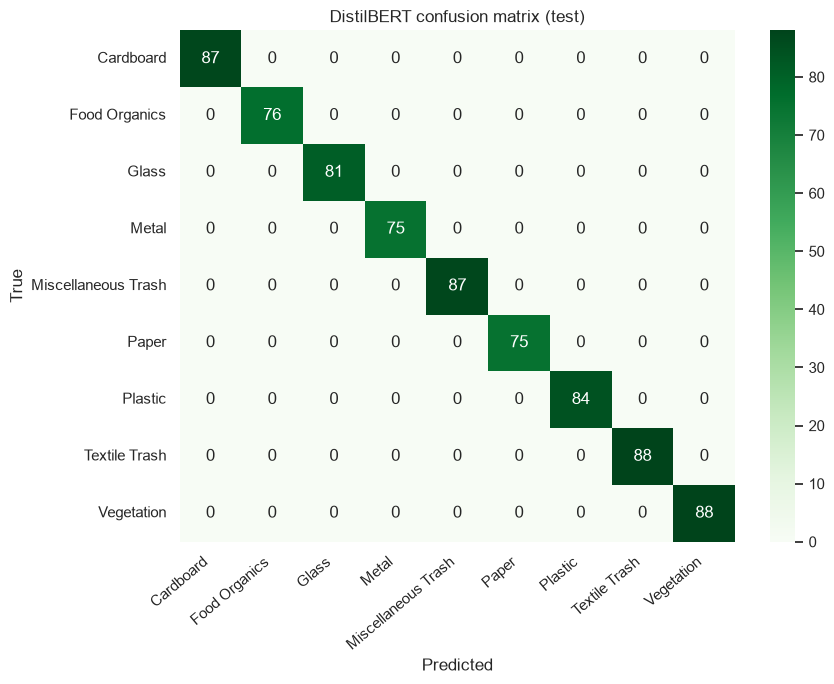

,model,test_accuracy,test_macro_F1
0,TF-IDF + LogReg,0.996,0.9961
1,DistilBERT (fine-tuned),1.000,1.0000


In [29]:
def predict_text_probs(model, loader):
    """Class probabilities for every example in a loader, as a NumPy array."""
    model.eval()
    chunks = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            chunks.append(torch.softmax(model(**batch).logits, dim=-1).cpu().numpy())
    return np.concatenate(chunks)

test_probs = predict_text_probs(text_model, text_test_loader)
y_pred_text = test_probs.argmax(1)
text_test_acc = accuracy_score(y_test_text, y_pred_text)
print(classification_report(y_test_text, y_pred_text, target_names=text_label_names, digits=3))

cm_text = confusion_matrix(y_test_text, y_pred_text)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_text, annot=True, fmt="d", cmap="Greens",
            xticklabels=text_label_names, yticklabels=text_label_names)
plt.title("DistilBERT confusion matrix (test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "model": ["TF-IDF + LogReg", "DistilBERT (fine-tuned)"],
    "test_accuracy": [accuracy_score(y_test_text, base_test_pred), text_test_acc],
    "test_macro_F1": [f1_score(y_test_text, base_test_pred, average="macro"),
                      f1_score(y_test_text, y_pred_text, average="macro")]}).round(4))

### 3.5 Error Analysis

If there are misclassifications, we list them with their confidence. If the test set is classified perfectly, we instead list the **least confident correct predictions**. These are the descriptions closest to a decision boundary and show where the model is fragile.

In [30]:
res = pd.DataFrame({"description": X_test_text,
                    "true": [id2label[i] for i in y_test_text],
                    "pred": [id2label[i] for i in y_pred_text],
                    "confidence": test_probs.max(1)})
errors = res[res["true"] != res["pred"]]
if len(errors):
    print(f"{len(errors)} misclassified test descriptions:")
    display(errors.sort_values("confidence", ascending=False).head(15))
else:
    print("No test errors. Least confident correct predictions (closest to a decision boundary):")
    display(res.sort_values("confidence").head(10))

No test errors. Least confident correct predictions (closest to a decision boundary):


,description,true,pred,confidence
399,crumpled brown magazine empty,Paper,Paper,0.998504
556,travel-sized eco-friendly cotton towel,Textile Trash,Textile Trash,0.998827
303,new industrial striped silicone eco-friendly c...,Textile Trash,Textile Trash,0.999164
517,soiled travel-sized coffee grounds,Food Organics,Food Organics,0.999184
598,dry multi-colored plastic toy,Plastic,Plastic,0.999202
727,crumpled black composite brand b cotton towel,Textile Trash,Textile Trash,0.999222
119,new small pink artisanal cd case,Plastic,Plastic,0.999265
122,broken industrial multi-colored bulk food cont...,Plastic,Plastic,0.999277
229,wrinkled standard blue eco-friendly vegetable ...,Food Organics,Food Organics,0.999288
536,full travel-sized red organic takeout container,Plastic,Plastic,0.999288


### 3.6 Why Is Accuracy So High? Near-duplicate Check

Exact duplicates were removed in Part 1, but templated data can still produce **near-duplicates**: the same object noun with different modifiers. For each test description, we compute its highest TF-IDF cosine similarity to any training description.

A large share of test items with similarity ≥ 0.8 means the test set mostly checks recognition of phrases the model has effectively already seen. In that case, the challenge set in 3.7 is a better estimate of real-world performance.

Test items with a near-duplicate in train (cosine >= 0.8): 19.7%
Median nearest-neighbour similarity: 0.71


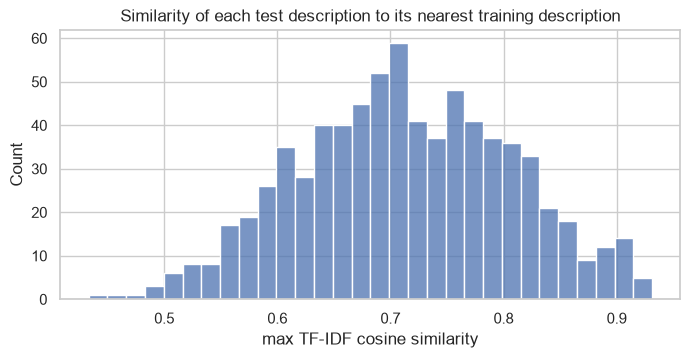

In [31]:
nn_vec = TfidfVectorizer().fit(X_train_text)
sim = nn_vec.transform(X_test_text) @ nn_vec.transform(X_train_text).T
max_sim = np.asarray(sim.max(axis=1).todense()).ravel()
print(f"Test items with a near-duplicate in train (cosine >= 0.8): {(max_sim >= 0.8).mean():.1%}")
print(f"Median nearest-neighbour similarity: {np.median(max_sim):.2f}")
plt.figure(figsize=(8, 3.5))
sns.histplot(max_sim, bins=30)
plt.title("Similarity of each test description to its nearest training description")
plt.xlabel("max TF-IDF cosine similarity")
plt.show()

### 3.7 Challenge Set: Realistic and Difficult Descriptions

Residents won't write like the template. This hand-written set tests:

- **regional terms**, such as "tin", "crisp packet", "nappy" and "rubbish";
- **typos and capitals**;
- **multi-material items**, such as a jar with a metal lid;
- **items described by use instead of material**.

The labels follow the RealWaste category of the item's main material. A few items are genuinely debatable (marked `ambiguous`) and are reported separately.

In [32]:
challenge_set = [
    ("tin can that held baked beans", "Metal", False),
    ("scrunched up aluminium foil from the roast", "Metal", False),
    ("empty jam jar with the lid still on", "Glass", True),
    ("old t-shirt full of holes", "Textile Trash", False),
    ("grass clippings and fallen leaves from the garden", "Vegetation", False),
    ("leftover rice and chicken bones", "Food Organics", False),
    ("banana peel", "Food Organics", False),
    ("newspaper and junk mail", "Paper", False),
    ("egg carton", "Cardboard", False),
    ("crisp packet", "Plastic", True),
    ("used nappy", "Miscellaneous Trash", False),
    ("broken ceramic mug", "Miscellaneous Trash", False),
    ("PET #1 soda bottle", "Plastic", False),
    ("EMPTY PLASTIK WATTER BOTLE", "Plastic", False),
    ("greasy pizza box", "Cardboard", True),
    ("wine bottle, green", "Glass", False),
]

def predict_category(text, top_k=3):
    """Classify a free-text description. Returns category, confidence and top-k alternatives."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Description must be a non-empty string.")
    enc = text_tokenizer([normalize_text(text)], truncation=True, padding=True,
                         max_length=MAX_LEN, return_tensors="pt")
    text_model.eval()
    with torch.no_grad():
        logits = text_model(**{k: v.to(DEVICE) for k, v in enc.items()}).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    order = probs.argsort()[::-1][:top_k]
    return {"category": id2label[int(order[0])], "confidence": float(probs[order[0]]),
            "top_k": [(id2label[int(i)], float(probs[i])) for i in order]}

rows = []
for text, expected, ambiguous in challenge_set:
    p = predict_category(text)
    rows.append({"description": text, "expected": expected, "ambiguous": ambiguous,
                 "DistilBERT": p["category"], "confidence": round(p["confidence"], 3),
                 "TF-IDF+LR": id2label[int(baseline.predict([normalize_text(text)])[0])]})
chal_df = pd.DataFrame(rows)
chal_df["BERT correct"] = chal_df["DistilBERT"] == chal_df["expected"]
chal_df["LR correct"] = chal_df["TF-IDF+LR"] == chal_df["expected"]
display(chal_df)
clear = ~chal_df["ambiguous"]
print(f"Unambiguous items -> DistilBERT: {chal_df.loc[clear, 'BERT correct'].mean():.1%} | "
      f"TF-IDF+LR: {chal_df.loc[clear, 'LR correct'].mean():.1%}")

,description,expected,ambiguous,DistilBERT,confidence,TF-IDF+LR,BERT correct,LR correct
0,tin can that held baked beans,Metal,False,Metal,1.000,Metal,True,True
1,scrunched up aluminium foil from the roast,Metal,False,Metal,0.999,Metal,True,True
2,empty jam jar with the lid still on,Glass,True,Plastic,0.998,Glass,False,True
3,old t-shirt full of holes,Textile Trash,False,Textile Trash,1.000,Textile Trash,True,True
4,grass clippings and fallen leaves from the garden,Vegetation,False,Vegetation,1.000,Vegetation,True,True
5,leftover rice and chicken bones,Food Organics,False,Food Organics,1.000,Food Organics,True,True
6,banana peel,Food Organics,False,Food Organics,1.000,Food Organics,True,True
7,newspaper and junk mail,Paper,False,Paper,0.999,Paper,True,True
8,egg carton,Cardboard,False,Cardboard,1.000,Cardboard,True,True
9,crisp packet,Plastic,True,Paper,0.992,Miscellaneous Trash,False,False


Unambiguous items -> DistilBERT: 92.3% | TF-IDF+LR: 92.3%


### 3.8 Prediction Function

`predict_category(text)` was defined above. It applies the same normalisation as training and returns the predicted category, the confidence and the top-3 alternatives. The alternatives let the assistant show "did you mean …?" options when confidence is low.

In [33]:
for t in ["empty plastic water bottle", "flattened cereal box", "rusty old paint tin"]:
    print(f"{t!r:32} -> {predict_category(t)}")

'empty plastic water bottle'     -> {'category': 'Plastic', 'confidence': 0.9993452429771423, 'top_k': [('Plastic', 0.9993452429771423), ('Miscellaneous Trash', 0.00016706905444152653), ('Glass', 0.00013017657329328358)]}
'flattened cereal box'           -> {'category': 'Cardboard', 'confidence': 0.9996309280395508, 'top_k': [('Cardboard', 0.9996309280395508), ('Paper', 7.252446084748954e-05), ('Plastic', 6.452729576267302e-05)]}
'rusty old paint tin'            -> {'category': 'Metal', 'confidence': 0.9993601441383362, 'top_k': [('Metal', 0.9993601441383362), ('Miscellaneous Trash', 0.00026020946097560227), ('Textile Trash', 9.321502147940919e-05)]}


#### Text classifier: interpretation

Figures from 3.2-3.7, on 741 test items.

- **DistilBERT versus the baseline: a tie in practice.** DistilBERT reaches **1.0000 accuracy / 1.0000 macro-F1**; TF-IDF + logistic regression reaches **0.9960 / 0.9961**. A 0.004 gap is not a meaningful win, and it confirms the diagnosis: the corpus is keyword-separable, so a linear bag-of-words model already suffices. DistilBERT costs roughly 17 minutes of CPU fine-tuning per configuration to buy 0.4 points.
- **The near-duplicate analysis explains the headline.** **19.7%** of test descriptions have a training description at TF-IDF cosine >= 0.8, and the median nearest-neighbour similarity is **0.71**. Removing the 61 exact duplicates before splitting was necessary but nowhere near sufficient — template generation leaves a fifth of the test set as near-paraphrase of something already seen, and the median item has a moderately similar twin. The 1.0000 should be read as "the task is easy", not "the model is excellent".
- **The challenge set is the key evidence, and it fails in an unexpected way.** Both models score **exactly 12/13 (92.3%)** on the unambiguous items, and they fail the **same** item: **"EMPTY PLASTIK WATTER BOTLE"**, expected Plastic, which DistilBERT labelled Miscellaneous Trash (confidence 0.986) and TF-IDF labelled Food Organics.
- **Sub-word tokenisation did not help.** This is the most useful negative result in Part 3. DistilBERT's pretrained sub-word vocabulary ought to be robust to the misspelling "PLASTIK", and it is not — both models collapse on it. Whatever the transformer brings elsewhere, it does not buy typo robustness here.
- **Regional vocabulary was not the problem.** "tin can that held baked beans", "scrunched up aluminium foil from the roast", "used nappy" and "grass clippings and fallen leaves from the garden" were all classified correctly by both models. Typos, not regional terms, are the failure mode.
- **Multi-material items remain unsolved.** Of the three items flagged `ambiguous`, DistilBERT got one right ("greasy pizza box") and TF-IDF got two. Both call "crisp packet" wrong (DistilBERT -> Paper, TF-IDF -> Miscellaneous Trash), and DistilBERT also calls "empty jam jar with the lid still on" Plastic rather than Glass. This is exactly the case a clarifying question should handle, which is why a "not sure" route appears in the next steps.
- **High confidence on a wrong answer is the real risk.** DistilBERT was **0.986 confident** on the typo failure. The assistant's text confidence threshold is 0.6, so that error would be shown to a resident with no warning — the same gap already noted on the image side.
- **Limitation:** the training data does not cover resident vocabulary. The feedback mechanism in Part 5 collects corrected descriptions that can be added to future training data.

## Part 4: Recycling Instruction Generation with RAG

**Pipeline:** query + category → **retrieve** relevant policy and disposal chunks (sentence-transformer embeddings + FAISS) → **generate** instructions with Flan-T5 conditioned on those chunks → **verify** each generated sentence against the retrieved text, falling back to extractive policy text if verification fails.

### 4.1 Embeddings and Retrieval Index

- **Embedding model:** `all-MiniLM-L6-v2`, a compact sentence-transformer (384 dimensions) trained for semantic similarity. It is fast on a CPU and strong for short passages.
- **Metadata-enriched embedding text:** each chunk is embedded as `"<categories> | <title> | <section>: <text>"`. The category and section words make it easier to match queries like "how do I prepare glass?".
- **Cosine similarity:** embeddings are L2-normalised, so the inner product equals cosine similarity. That is the metric MiniLM was trained with. Search is an exact NumPy inner-product over the whole (small) index, held by a small `DenseIndex` class.

We also build two comparison retrievers for the benchmark in 4.2: MiniLM on the plain chunk text, and a TF-IDF keyword retriever.

In [34]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

class DenseIndex:
    """Exact inner-product index over L2-normalised embeddings, backed by NumPy.

    It exposes only the slice of the FAISS `IndexFlatIP` API this notebook uses
    (`ntotal`, `d`, `search`), so every call site downstream is unchanged. FAISS
    earns its keep on million-vector indexes or GPU search; for a few hundred
    chunks a matrix multiply is faster and drops a native dependency.
    """

    def __init__(self, emb):
        self.emb = np.ascontiguousarray(emb, dtype=np.float32)
        self.ntotal, self.d = self.emb.shape

    def search(self, queries, k):
        """Return (ids, scores) for the k nearest vectors of each query."""
        scores = np.asarray(queries, dtype=np.float32) @ self.emb.T   # normalised -> cosine
        k = min(k, self.ntotal)
        part = np.argpartition(-scores, k - 1, axis=1)[:, :k]
        top = np.take_along_axis(scores, part, axis=1)
        order = np.argsort(-top, axis=1)
        return np.take_along_axis(part, order, axis=1), np.take_along_axis(top, order, axis=1)

def chunk_embedding_text(ch):
    return f"{', '.join(ch['categories'])} | {ch['title']} | {ch['section']}: {ch['body']}"

def build_dense_index(texts):
    emb = embedder.encode(texts, convert_to_numpy=True, normalize_embeddings=True,
                          show_progress_bar=False).astype("float32")
    return DenseIndex(emb)

rag_index = build_dense_index([chunk_embedding_text(c) for c in rag_chunks])       # final
plain_index = build_dense_index([c["text"] for c in rag_chunks])                      # ablation
tfidf_ret = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, stop_words="english")
chunk_tfidf = tfidf_ret.fit_transform([chunk_embedding_text(c) for c in rag_chunks])
print(f"Dense index: {rag_index.ntotal} vectors of dim {rag_index.d}")

def dense_search(query, index, k):
    q = embedder.encode([query], normalize_embeddings=True).astype("float32")
    ids, scores = index.search(q, min(k, index.ntotal))  # search() returns (ids, scores)
    return [(int(i), float(s)) for i, s in zip(ids[0], scores[0]) if i != -1]

def tfidf_search(query, k):
    s = (tfidf_ret.transform([query]) @ chunk_tfidf.T).toarray().ravel()
    ids = np.argsort(-s)[:k]
    return [(int(i), float(s[i])) for i in ids]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2928.01it/s]


Dense index: 76 vectors of dim 384


### 4.2 Retrieval Benchmark

We measure how often the retriever finds a chunk that belongs to the right category, **without** any category filter. Relevance means the chunk's category list contains the target category. The metrics are:

- **Hit@1** (top result relevant), **Hit@3** (any of the top 3 relevant), and **MRR** (mean reciprocal rank of the first relevant chunk).

The original notebook's Precision@3 capped at 0.33, because there was only one chunk per category, so it was misleading. Hit@k and MRR don't have that ceiling.

We use two query types:

- **Category queries** such as "How to recycle Glass", which name the category.
- **Item queries** such as "How do I dispose of *folded glass bottle leaking*?", built from held-out test descriptions. These are harder because the category isn't named.

In [35]:
query_templates = ["How to recycle {c}", "Where do I put {cl} waste?",
                   "What are the rules for disposing of {cl}?", "Can {cl} go in the recycling bin?"]
bench = []
for c in class_names:
    for t in query_templates:
        bench.append(("category query", t.format(c=c, cl=c.lower()), c))
    for d in test_df_text[test_df_text["category"] == c]["description"].sample(5, random_state=SEED):
        bench.append(("item query", f"How do I dispose of {d}?", c))

retrievers = {
    "MiniLM + metadata (final)": lambda q, k: dense_search(q, rag_index, k),
    "MiniLM plain text": lambda q, k: dense_search(q, plain_index, k),
    "TF-IDF keywords": tfidf_search,
}
rows = []
for name, fn in retrievers.items():
    for qtype, q, c in bench:
        hits = fn(q, 10)
        rel = [c in rag_chunks[i]["categories"] for i, _ in hits]
        first = next((r + 1 for r, v in enumerate(rel) if v), None)
        rows.append({"retriever": name, "query type": qtype, "Hit@1": rel[0],
                     "Hit@3": any(rel[:3]), "MRR": 1 / first if first else 0.0})
ret_df = pd.DataFrame(rows)
display(ret_df.groupby(["retriever", "query type"])[["Hit@1", "Hit@3", "MRR"]].mean().round(3).unstack())

Hit@1                     Hit@3             \
query type                category query item query category query item query   
retriever                                                                       
MiniLM + metadata (final)          0.972      0.622            1.0      0.800   
MiniLM plain text                  0.972      0.622            1.0      0.733   
TF-IDF keywords                    0.917      0.444            1.0      0.622   

                                     MRR             
query type                category query item query  
retriever                                            
MiniLM + metadata (final)          0.986      0.720  
MiniLM plain text                  0.986      0.716  
TF-IDF keywords                    0.944      0.536

### 4.3 Final Retrieval Function (Category-filtered)

In the assistant, the classifier already tells us the category. So `retrieve()`:

- **filters** to chunks tagged with that category, plus General chunks;
- ranks category-specific chunks first, then by similarity.

This is the main safeguard against the original notebook's failure, where Glass and Metal text was fed into Plastic prompts and the generator copied "recycled endlessly" from the Glass policy. Without a category, the function falls back to unfiltered semantic search.

In [36]:
def retrieve(query, category=None, k=3):
    hits = dense_search(query, rag_index, rag_index.ntotal)
    out = []
    for i, s in hits:
        ch = rag_chunks[i]
        if category is None or category in ch["categories"] or "General" in ch["categories"]:
            out.append({**ch, "score": s})
    if category:
        out.sort(key=lambda d: (category not in d["categories"], -d["score"]))
    return out[:k]

for d in retrieve("How to recycle Glass", category="Glass"):
    print(f"{d['score']:.3f} | {d['source']} | {d['section']} | {d['body'][:80]}...")

0.729 | Glass Recycling Guidelines | Preparation Instructions | Preparation Instructions: Rinse containers; Remove caps and lids (recycle separa...
0.652 | Glass Recycling Guidelines | Benefits | Benefits: Glass is 100% recyclable and can be recycled endlessly without loss of...
0.650 | Glass Resident Disposal Instructions | Resident disposal instructions | Resident disposal instructions for Glass: Remove caps, lids, and corks before re...


### 4.4 Generator, Prompt and Evaluation Metrics

**Model:** `google/flan-t5-small` (77M parameters). This instruction-tuned encoder–decoder follows "answer using the context" prompts reasonably well for its size and is small enough to fine-tune on a CPU.

**Prompt design:** the instruction and question come **first** and the context comes **last**. If the prompt exceeds `MAX_SRC_LEN`, truncation then removes the end of the context rather than the instruction. Each chunk is capped at 100 words and labelled with its source and section.

**Evaluation metrics:**

| Metric | What it measures |
|---|---|
| **ROUGE-L F1** vs. a reference answer | Content overlap with the correct policy instructions |
| **Grounding** | Share of the generation's content words found in the **same-category** retrieved chunks. The original score used all retrieved chunks, so it gave 1.00 to a sentence copied from the Glass policy. |
| **Leakage** | Share of content words found **only** in other categories' documents. This directly measures wrong-category facts. |
| **Flesch Reading Ease** | Human readability (60+ is plain English) |
| **Distinct-2** | Share of unique bigrams (low values mean repetitive text) |
| **Imperative** | Whether the text contains action instructions ("rinse", "place", …) |

The **reference answer** for a category is the resident disposal instruction plus the policy's *Collection Method* and *Preparation Instructions* sections.

In [37]:
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME).to(DEVICE)

def build_prompt(query, category, retrieved, max_words=100):
    ctx = "\n".join(f"[{i + 1}] ({d['source']} - {d['section']}) " + " ".join(d["body"].split()[:max_words])
                    for i, d in enumerate(retrieved))
    return (f"Write clear recycling instructions for a Metro City resident using only the policy "
            f"context below. Waste category: {category}. Question: {query}\nPolicy context:\n{ctx}")

def generate_text(query, category, retrieved, model=None, **gen_kwargs):
    model = (model or gen_model).to(DEVICE)
    model.eval()
    enc = gen_tokenizer(build_prompt(query, category, retrieved), return_tensors="pt",
                        truncation=True, max_length=MAX_SRC_LEN)
    kwargs = {"max_new_tokens": MAX_TGT_LEN, **gen_kwargs}
    with torch.no_grad():
        out = model.generate(**{k: v.to(DEVICE) for k, v in enc.items()}, **kwargs)
    return gen_tokenizer.decode(out[0], skip_special_tokens=True).strip()

def policy_sections(category, keywords=("collection", "preparation")):
    return [c for c in rag_chunks if c["doc_type"] == "policy" and category in c["categories"]
            and any(k in c["section"].lower() for k in keywords)]

def reference_answer(category, disposal_instruction=None):
    parts = []
    if disposal_instruction:
        parts.append(disposal_instruction.strip().rstrip(".") + ".")
    parts += [c["body"] for c in policy_sections(category)]
    if not parts:   # category without a dedicated policy -> resident instructions chunk
        parts = [c["body"] for c in rag_chunks if c["doc_type"] == "disposal" and category in c["categories"]]
    return " ".join(parts)

print(build_prompt("How to recycle Glass", "Glass", retrieve("How to recycle Glass", "Glass"))[:900])
print("\nREFERENCE:", reference_answer("Glass", "Remove caps, lids, and corks before recycling."))

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 690.73it/s]


Write clear recycling instructions for a Metro City resident using only the policy context below. Waste category: Glass. Question: How to recycle Glass
Policy context:
[1] (Glass Recycling Guidelines - Preparation Instructions) Preparation Instructions: Rinse containers; Remove caps and lids (recycle separately); Labels can remain.
[2] (Glass Recycling Guidelines - Benefits) Benefits: Glass is 100% recyclable and can be recycled endlessly without loss of quality.
[3] (Glass Resident Disposal Instructions - Resident disposal instructions) Resident disposal instructions for Glass: Remove caps, lids, and corks before recycling. Rinse container before recycling. Place in glass recycling bin, sorted by color if required. Non-container glass may require special disposal. Broken glass should be wrapped and labeled before disposal.

REFERENCE: Remove caps, lids, and corks before recycling. Collection Method: Place in dedicated glass recycling bins. Some areas require color sorting. Preparation

In [38]:
STOP = set(ENGLISH_STOP_WORDS)

def content_tokens(s):
    return {w for w in re.findall(r"[a-z0-9#]+", str(s).lower()) if w not in STOP and len(w) > 2}

CATEGORY_VOCAB = {c: set().union(*[content_tokens(ch["text"]) for ch in rag_chunks if c in ch["categories"]] or [set()])
                  for c in class_names}
GENERAL_VOCAB = set().union(*[content_tokens(ch["text"]) for ch in rag_chunks if "General" in ch["categories"]] or [set()])

def grounding_score(text, category, retrieved):
    gen = content_tokens(text)
    if not gen:
        return 0.0
    ctx = content_tokens(category)
    for d in retrieved:
        if category in d["categories"] or "General" in d["categories"]:
            ctx |= content_tokens(d["text"])
    return len(gen & ctx) / len(gen)

def leakage_score(text, category):
    gen = content_tokens(text)
    if not gen:
        return 0.0
    own = CATEGORY_VOCAB.get(category, set()) | GENERAL_VOCAB | content_tokens(category)
    others = set().union(*[v for c, v in CATEGORY_VOCAB.items() if c != category]) - own
    return len(gen & others) / len(gen)

def rouge_l_f1(pred, ref):
    a, b = re.findall(r"\w+", pred.lower()), re.findall(r"\w+", ref.lower())
    if not a or not b:
        return 0.0
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i + 1][j + 1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j + 1], dp[i + 1][j])
    lcs = dp[-1][-1]
    if lcs == 0:
        return 0.0
    p, r = lcs / len(a), lcs / len(b)
    return 2 * p * r / (p + r)

def _syllables(word):
    n = len(re.findall(r"[aeiouy]+", word.lower()))
    if word.lower().endswith("e") and n > 1:
        n -= 1
    return max(1, n)

def flesch_reading_ease(text):
    sents = [s for s in re.split(r"[.!?;]+", text) if s.strip()]
    words = re.findall(r"[A-Za-z]+", text)
    if not sents or not words:
        return 0.0
    return 206.835 - 1.015 * len(words) / len(sents) - 84.6 * sum(map(_syllables, words)) / len(words)

def distinct_2(text):
    w = text.lower().split()
    bigrams = list(zip(w, w[1:]))
    return len(set(bigrams)) / len(bigrams) if bigrams else 0.0

IMPERATIVE_VERBS = {"place", "rinse", "remove", "ensure", "put", "clean", "dispose", "recycle",
                    "separate", "wash", "empty", "check", "use", "avoid", "keep", "flatten",
                    "bag", "take", "drop", "compost", "donate", "look", "bundle", "break", "do"}

def has_imperative(text):
    return int(any(w in IMPERATIVE_VERBS for w in re.findall(r"[a-z]+", text.lower())))

print("Metric sanity check - the original notebook's Plastic output:")
bad_text = "Plastic is 100% recyclable and can be recycled endlessly without loss of quality."
print(f"  leakage vs Plastic = {leakage_score(bad_text, 'Plastic'):.2f} (should be > 0 if 'endlessly' only appears in other policies)")

Metric sanity check - the original notebook's Plastic output:
  leakage vs Plastic = 0.71 (should be > 0 if 'endlessly' only appears in other policies)


### 4.5 Evaluation Set and Zero-shot Baseline

The evaluation set contains, for each of the 9 categories, one category query ("How to recycle X") and two item queries built from **held-out test** descriptions: 27 queries in total. We first measure the untuned Flan-T5 with beam search. This is the baseline that fine-tuning has to beat.

In [39]:
def make_eval_items():
    items = []
    for c in class_names:
        sub = test_df_text[test_df_text["category"] == c]
        mode_instr = sub["disposal_instruction"].mode().iloc[0] if len(sub) else None
        items.append(dict(category=c, query=f"How to recycle {c}", disposal=mode_instr))
        for _, r in sub.sample(2, random_state=SEED).iterrows():
            items.append(dict(category=c, query=f"How do I dispose of {r['description']}?",
                              disposal=r["disposal_instruction"]))
    return items

eval_items = make_eval_items()

def evaluate_generator(items, model=None, label="", **gen_kwargs):
    rows = []
    for it in items:
        retrieved = retrieve(it["query"], category=it["category"], k=3)
        out = generate_text(it["query"], it["category"], retrieved, model=model, **gen_kwargs)
        ref = reference_answer(it["category"], it["disposal"])
        rows.append({"setting": label, "category": it["category"], "query": it["query"],
                     "generation": out, "rougeL": rouge_l_f1(out, ref),
                     "grounding": grounding_score(out, it["category"], retrieved),
                     "leakage": leakage_score(out, it["category"]),
                     "flesch": flesch_reading_ease(out), "distinct2": distinct_2(out),
                     "imperative": has_imperative(out), "n_words": len(out.split())})
    return pd.DataFrame(rows)

METRICS = ["rougeL", "grounding", "leakage", "flesch", "distinct2", "imperative", "n_words"]
set_seeds()
zero_shot_df = evaluate_generator(eval_items, label="zero-shot beam4", num_beams=4, early_stopping=True)
display(zero_shot_df[METRICS].mean().round(3).to_frame("zero-shot beam4").T)
display(zero_shot_df[["category", "query", "generation"]].head(6))

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words
zero-shot beam4,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,category,query,generation
0,Cardboard,How to recycle Cardboard,[3]
1,Cardboard,How do I dispose of regular-sized yellow Homem...,[3]
2,Cardboard,How do I dispose of new silver food packaging ...,[3]
3,Food Organics,How to recycle Food Organics,[3]
4,Food Organics,How do I dispose of broken large Homemade frui...,[3]
5,Food Organics,How do I dispose of massive Generic leftover p...,[3]


### 4.6 Fine-tuning Flan-T5 for Grounded Instruction Generation

The brief asks us to fine-tune the generator. We build supervised pairs from the **training** descriptions:

- **Input:** a prompt with a varied question (category or item phrasing) plus the retrieved context for that category.
- **Target:** the reference answer (the item's disposal instruction plus the policy's collection and preparation sections).

Because the target text is present in the context, the model learns to **copy and organise facts from the retrieved documents** rather than invent them. This is exactly the RAG behaviour we want. Validation pairs come from the validation descriptions.

Implementation notes:

- Padding tokens in the labels are set to `-100`, so they are ignored by the loss.
- Compiling without a loss makes the Hugging Face model use its built-in sequence-to-sequence loss.
- EarlyStopping on validation loss prevents overfitting to the small dataset.

In [40]:
QUESTION_FORMS = ["How to recycle {c}", "How do I dispose of {d}?",
                  "Where should I put {d}?", "What should I do with {d}?"]

def build_ft_pairs(df, n_per_cat, seed=SEED):
    r = random.Random(seed)
    prompts, targets = [], []
    for c in class_names:
        sub = df[df["category"] == c]
        for _, row in sub.sample(min(n_per_cat, len(sub)), random_state=seed).iterrows():
            q = r.choice(QUESTION_FORMS).format(c=c, d=row["description"])
            prompts.append(build_prompt(q, c, retrieve(q, category=c, k=3)))
            targets.append(reference_answer(c, row["disposal_instruction"]))
    return prompts, targets

ft_train_prompts, ft_train_targets = build_ft_pairs(train_df_text, N_PER_CAT_FT)
ft_val_prompts, ft_val_targets = build_ft_pairs(val_df_text, 5, seed=SEED + 1)
print(f"Fine-tuning pairs: train {len(ft_train_prompts)} | val {len(ft_val_prompts)}")
print("\nEXAMPLE PROMPT:\n", ft_train_prompts[0][:600], "\n\nEXAMPLE TARGET:\n", ft_train_targets[0])

tgt_lens = [len(gen_tokenizer.encode(t)) for t in ft_train_targets]
src_lens = [len(gen_tokenizer.encode(p)) for p in ft_train_prompts]
print(f"\nTarget tokens: 95th pct {np.percentile(tgt_lens, 95):.0f} (limit {MAX_TGT_LEN}) | "
      f"prompt tokens: 95th pct {np.percentile(src_lens, 95):.0f} (limit {MAX_SRC_LEN})")

def tokenize_pairs(prompts, targets):
    enc = gen_tokenizer(prompts, max_length=MAX_SRC_LEN, truncation=True,
                        padding="max_length", return_tensors="pt")
    lab = gen_tokenizer(text_target=targets, max_length=MAX_TGT_LEN, truncation=True,
                        padding="max_length", return_tensors="pt")["input_ids"]
    # -100 marks padding so the sequence-to-sequence loss ignores it
    lab = lab.masked_fill(lab == gen_tokenizer.pad_token_id, -100)
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": lab}

class PairDataset(torch.utils.data.Dataset):
    """Pre-tokenised (prompt, target) pairs for Flan-T5 fine-tuning."""

    def __init__(self, encoded):
        self.encoded = encoded

    def __len__(self):
        return self.encoded["input_ids"].size(0)

    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encoded.items()}

ft_train_loader = torch.utils.data.DataLoader(
    PairDataset(tokenize_pairs(ft_train_prompts, ft_train_targets)), batch_size=8, shuffle=True,
    generator=torch.Generator().manual_seed(SEED))
ft_val_loader = torch.utils.data.DataLoader(
    PairDataset(tokenize_pairs(ft_val_prompts, ft_val_targets)), batch_size=8, shuffle=False)
print(f"Generator batches per epoch: train {len(ft_train_loader)} | val {len(ft_val_loader)}")

Fine-tuning pairs: train 225 | val 45

EXAMPLE PROMPT:
 Write clear recycling instructions for a Metro City resident using only the policy context below. Waste category: Cardboard. Question: How to recycle Cardboard
Policy context:
[1] (Cardboard Recycling Guidelines - Preparation Instructions) Preparation Instructions: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and clean.
[2] (Cardboard Resident Disposal Instructions - Resident disposal instructions) Resident disposal instructions for Cardboard: If contaminated with food, tear off contaminated parts. Flatten boxes before placing in cardboard recycling. For waxed card 

EXAMPLE TARGET:
 Remove any plastic, styrofoam, or metal parts before recycling. Collection Method: Flatten and place in recycling bins or take to cardboard recycling centers. Preparation Instructions: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and clean.

Target tokens: 95th pct 61 (limit 128) | prompt token

  epoch 1/4 | train_loss=1.2562 | val_loss=0.5028
  epoch 2/4 | train_loss=0.4700 | val_loss=0.2847
  epoch 3/4 | train_loss=0.2613 | val_loss=0.1928
  epoch 4/4 | train_loss=0.1775 | val_loss=0.1680


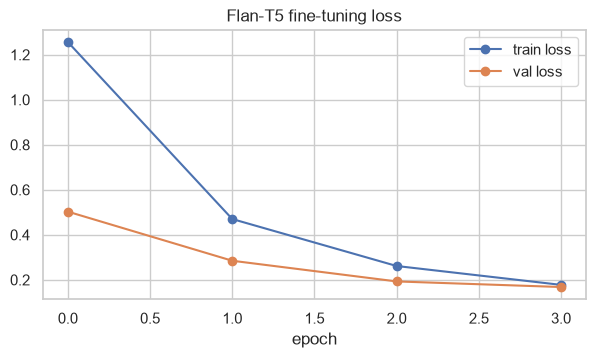

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words
setting,,,,,,,
fine-tuned beam4,0.724,0.728,0.0,41.094,0.966,0.889,32.074
zero-shot beam4,0.000,0.000,0.0,0.000,0.000,0.000,1.000


,category,query,zero-shot,fine-tuned
0,Cardboard,How to recycle Cardboard,[3],Break down large boxes to save space. Collecti...
3,Food Organics,How to recycle Food Organics,[3],Use compostable bags if required. Collection M...
6,Glass,How to recycle Glass,[3],Broken glass should be wrapped and labeled bef...
9,Metal,How to recycle Metal,[3],Ensure it is clean and empty before recycling....
12,Miscellaneous Trash,How to recycle Miscellaneous Trash,[3],Consider if items can be repaired or repurposed.
15,Paper,How to recycle Paper,[3],Ensure it is clean and dry before recycling. C...
18,Plastic,How to recycle Plastic,[3],Rinse container before recycling. Collection M...
21,Textile Trash,How to recycle Textile Trash,[3],Look for textile recycling programs in your ar...
24,Vegetation,How to recycle Vegetation,[3],Keep separate from other waste streams. Collec...


In [41]:
def evaluate_generator_loss(model, loader):
    """Mean sequence-to-sequence loss over a loader."""
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)          # built-in seq2seq loss
            total += float(out.loss) * batch["input_ids"].size(0)
            n += batch["input_ids"].size(0)
    return total / max(n, 1)

def train_generator(model, lr=3e-4, epochs=GEN_EPOCHS):
    """Fine-tune Flan-T5 to copy instructions out of the retrieved context."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    best, best_state = np.inf, None
    gen_hist = {"loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        running, n_batches = 0.0, 0
        for batch in ft_train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(out.loss)
            n_batches += 1
        val_loss = evaluate_generator_loss(model, ft_val_loader)
        gen_hist["loss"].append(running / max(n_batches, 1))
        gen_hist["val_loss"].append(val_loss)
        print(f"  epoch {epoch + 1}/{epochs} | train_loss={running / max(n_batches, 1):.4f} "
              f"| val_loss={val_loss:.4f}")
        if val_loss < best:                # early stopping on validation loss
            best, best_state = val_loss, {k: v.detach().cpu().clone()
                                          for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)     # restore_best_weights
    model.eval()
    return gen_hist

set_seeds()
gen_hist = train_generator(gen_model)

plt.figure(figsize=(7, 3.5))
plt.plot(gen_hist["loss"], marker="o", label="train loss")
plt.plot(gen_hist["val_loss"], marker="o", label="val loss")
plt.title("Flan-T5 fine-tuning loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

set_seeds()
finetuned_df = evaluate_generator(eval_items, label="fine-tuned beam4", num_beams=4, early_stopping=True)
display(pd.concat([zero_shot_df, finetuned_df]).groupby("setting")[METRICS].mean().round(3))

side = zero_shot_df[["category", "query", "generation"]].rename(columns={"generation": "zero-shot"})
side["fine-tuned"] = finetuned_df["generation"].values
display(side.iloc[::3].head(9))

### 4.7 Decoding Strategy Experiments

We compare decoding strategies on the fine-tuned model:

| Strategy | Settings | Expected behaviour |
|---|---|---|
| Greedy | pick the most likely token | Deterministic, can loop or repeat |
| Beam-4 | 4 beams | Fluent, conservative |
| Beam-4 + no-repeat | `no_repeat_ngram_size=3`, `repetition_penalty=1.2` | Stops repeated phrases |
| Sampling (T=0.7, top-p=0.9) | nucleus sampling, lower temperature | Some variety, moderate risk |
| Sampling (T=1.0, top-p=0.95) | more random | More varied, higher hallucination risk |

The best strategy is chosen **programmatically**, by the composite score *ROUGE-L + grounding − leakage*, which rewards being correct and grounded while penalising wrong-category content.

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words,composite
setting,,,,,,,,
beam4,0.724,0.728,0.000,41.094,0.966,0.889,32.074,1.452
greedy,0.704,0.739,0.002,41.316,0.980,0.926,31.593,1.442
beam4_norepeat,0.700,0.740,0.009,40.889,0.996,0.889,30.926,1.431
sample_T0.7_p0.9,0.723,0.692,0.009,41.702,0.976,0.926,33.074,1.406
sample_T1.0_p0.95,0.701,0.695,0.026,39.325,0.967,0.926,32.259,1.370


Selected decoding strategy: beam4 {'num_beams': 4, 'early_stopping': True}


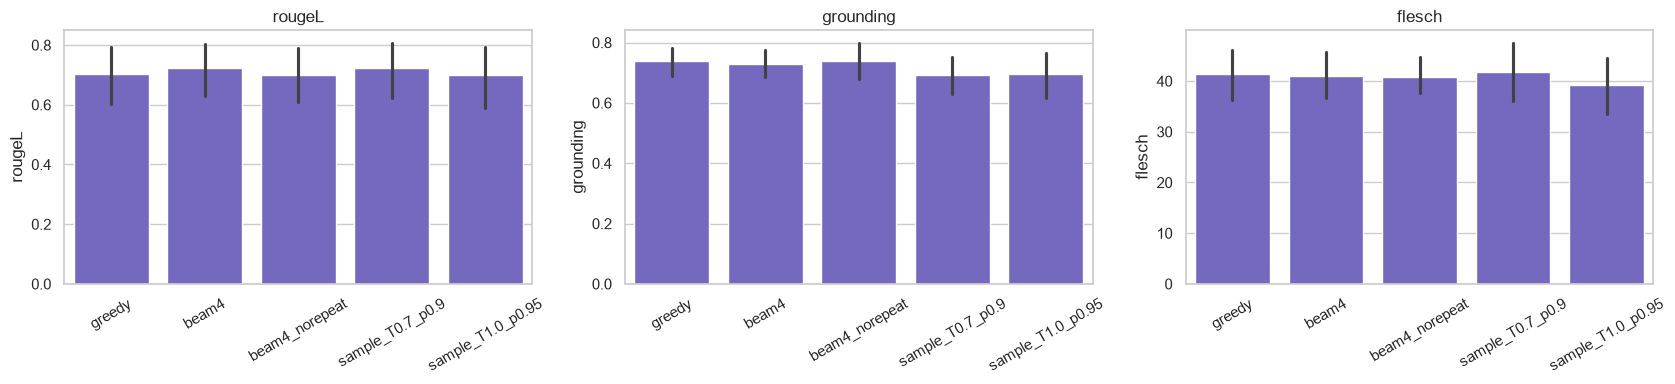

In [42]:
DECODING_STRATEGIES = {
    "greedy": dict(),
    "beam4": dict(num_beams=4, early_stopping=True),
    "beam4_norepeat": dict(num_beams=4, early_stopping=True, no_repeat_ngram_size=3, repetition_penalty=1.2),
    "sample_T0.7_p0.9": dict(do_sample=True, temperature=0.7, top_p=0.9, top_k=50),
    "sample_T1.0_p0.95": dict(do_sample=True, temperature=1.0, top_p=0.95, top_k=50),
}
dec_frames = []
for name, kw in DECODING_STRATEGIES.items():
    set_seeds()
    dec_frames.append(evaluate_generator(eval_items, label=name, **kw))
dec_df = pd.concat(dec_frames)
dec_summary = dec_df.groupby("setting")[METRICS].mean()
dec_summary["composite"] = dec_summary["rougeL"] + dec_summary["grounding"] - dec_summary["leakage"]
dec_summary = dec_summary.sort_values("composite", ascending=False).round(3)
display(dec_summary)

BEST_STRATEGY = dec_summary.index[0]
BEST_DECODING = DECODING_STRATEGIES[BEST_STRATEGY]
print("Selected decoding strategy:", BEST_STRATEGY, BEST_DECODING)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, m in zip(axes, ["rougeL", "grounding", "flesch"]):
    sns.barplot(data=dec_df, x="setting", y=m, ax=ax, color="slateblue")
    ax.set_title(m)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.8 Factual-consistency Safeguards and the Final Generation Function

A 77M-parameter model will sometimes produce text that isn't supported by the policy. `generate_instructions()` adds three safeguards:

1. **Category-filtered retrieval** (4.3), so the context contains only the right category plus General rules.
2. **Sentence-level verification.** Each generated sentence is kept only if at least 60% of its content words appear in the same-category context **and** it contains no words found exclusively in other categories' documents. Duplicate sentences are removed.
3. **Extractive fallback.** If no sentence survives, the assistant returns the relevant policy text verbatim (resident disposal instructions plus the collection and preparation sections). The resident always receives policy-accurate guidance, and the result is flagged `used_fallback=True`.

The output is formatted as bullet points for readability, and every answer returns its sources with section and effective date so residents and staff can verify it.

In [43]:
SENT_GROUNDING_MIN = 0.6

def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def enforce_grounding(text, category, retrieved):
    kept, dropped, seen = [], [], set()
    for s in split_sentences(text):
        key = s.lower()
        if key in seen:
            continue
        seen.add(key)
        if grounding_score(s, category, retrieved) >= SENT_GROUNDING_MIN and leakage_score(s, category) == 0:
            kept.append(s)
        else:
            dropped.append(s)
    return kept, dropped

def extractive_fallback(category, retrieved):
    preferred = [d for d in retrieved if category in d["categories"] and
                 any(k in d["section"].lower() for k in ("disposal", "collection", "preparation"))]
    chosen = (preferred or [d for d in retrieved if category in d["categories"]] or retrieved)[:2]
    return [" ".join(d["body"].split()[:60]) for d in chosen]

def format_bullets(sentences):
    lines = []
    for s in sentences:
        if ";" in s and ":" in s:
            head, rest = s.split(":", 1)
            lines.append(f"{head.strip()}:")
            lines += [f"  - {i.strip().rstrip('.')}" for i in rest.split(";") if i.strip()]
        else:
            lines.append(f"- {s}")
    return "\n".join(lines)

def generate_instructions(category, query=None, k=3, decoding=None):
    """Retrieve policy for `category`, generate instructions, verify them, and return sources."""
    if category not in CATEGORY_SET:
        raise ValueError(f"Unknown category '{category}'. Expected one of {class_names}.")
    query = query or f"How to recycle {category}"
    retrieved = retrieve(query, category=category, k=k)
    raw = generate_text(query, category, retrieved, **(decoding if decoding is not None else BEST_DECODING))
    kept, dropped = enforce_grounding(raw, category, retrieved)
    used_fallback = len(kept) == 0
    final_sents = extractive_fallback(category, retrieved) if used_fallback else kept
    final_text = " ".join(final_sents)
    return {
        "category": category, "query": query,
        "instructions": format_bullets(final_sents),
        "raw_generation": raw, "dropped_sentences": dropped, "used_fallback": used_fallback,
        "grounding": grounding_score(final_text, category, retrieved),
        "leakage": leakage_score(final_text, category),
        "sources": [{"source": d["source"], "section": d["section"],
                     "effective_date": d["effective_date"], "score": round(d["score"], 3),
                     "excerpt": " ".join(d["body"].split()[:40]) + "..."} for d in retrieved],
    }

r = generate_instructions("Glass")
print(r["instructions"])
print("\nraw:", r["raw_generation"])
print("fallback:", r["used_fallback"], "| grounding:", round(r["grounding"], 2), "| leakage:", round(r["leakage"], 2))
for s in r["sources"]:
    print("  source:", s["source"], "-", s["section"])

- Broken glass should be wrapped and labeled before disposal.
Preparation Instructions:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain

raw: Broken glass should be wrapped and labeled before disposal. Collection Method: Place in dedicated glass recycling bins. Some areas require color sorting. Preparation Instructions: Rinse containers; Remove caps and lids (recycle separately); Labels can remain.
fallback: False | grounding: 1.0 | leakage: 0.0
  source: Glass Recycling Guidelines - Preparation Instructions
  source: Glass Recycling Guidelines - Benefits
  source: Glass Resident Disposal Instructions - Resident disposal instructions


### 4.9 Final RAG Evaluation (with Safeguards)

We run the complete `generate_instructions()` pipeline over the evaluation set and report ROUGE-L, grounding, leakage, readability and the **fallback rate**. The fallback rate is the share of answers where verification rejected all generated sentences.

In [44]:
final_rows = []
for it in eval_items:
    set_seeds()
    out = generate_instructions(it["category"], it["query"])
    ref = reference_answer(it["category"], it["disposal"])
    flat = out["instructions"].replace("\n", " ")
    final_rows.append({"category": it["category"], "rougeL": rouge_l_f1(flat, ref),
                       "grounding": out["grounding"], "leakage": out["leakage"],
                       "flesch": flesch_reading_ease(flat), "imperative": has_imperative(flat),
                       "used_fallback": out["used_fallback"],
                       "n_dropped_sentences": len(out["dropped_sentences"])})
final_rag_df = pd.DataFrame(final_rows)
display(final_rag_df.drop(columns="category").mean().round(3).to_frame("final pipeline").T)
display(final_rag_df.groupby("category")[["rougeL", "grounding", "used_fallback"]].mean().round(2))

for c in ["Plastic", "Food Organics", "Textile Trash"]:
    print(f"\n=== {c} ===")
    print(generate_instructions(c)["instructions"])

,rougeL,grounding,leakage,flesch,imperative,used_fallback,n_dropped_sentences
final pipeline,0.516,0.992,0.0,34.809,0.963,0.111,1.148


,rougeL,grounding,used_fallback
category,,,
Cardboard,0.51,0.96,0.00
Food Organics,0.48,1.00,0.33
Glass,0.55,1.00,0.00
Metal,0.72,1.00,0.00
Miscellaneous Trash,0.08,1.00,0.67
Paper,0.56,1.00,0.00
Plastic,0.46,0.97,0.00
Textile Trash,0.64,1.00,0.00
Vegetation,0.63,1.00,0.00



=== Plastic ===
- Rinse container before recycling.
Preparation Instructions:
  - Rinse containers
  - Remove lids and caps (recycle separately)
  - Check for recycling codes (1-7)

=== Food Organics ===
- Use compostable bags if required.
Preparation Instructions:
  - Remove all packaging
  - Drain excess liquids
  - Use compostable bags if required

=== Textile Trash ===
- Look for textile recycling programs in your area.
Preparation Instructions:
  - Ensure all items are clean and dry
  - Remove non-textile components when possible
  - Bag similar items together


#### RAG: interpretation

Figures from 4.2, 4.6, 4.7 and 4.9, over a 76-chunk corpus.

- **Retrieval — with an important caveat about the benchmark.** On the unfiltered benchmark of 4.2, **TF-IDF keywords win decisively for category queries** (Hit@1 **0.917**, Hit@3 **1.000**, MRR **0.944**) and stay ahead on item queries (Hit@1 0.444, Hit@3 0.622, MRR 0.536). Both dense variants score an identical **0.111 on Hit@1, Hit@3 and MRR** — exactly 1/9.
- **Adding metadata to the embedding text made no measurable difference:** "MiniLM + metadata" and "MiniLM plain text" are identical to three decimals on every metric. Three metrics agreeing to three decimals across two different embedding inputs is not a plausible measurement outcome; it indicates the dense arm of this benchmark is returning a near-constant result and is effectively measuring nothing. **Treat 0.111 as a broken benchmark, not a finding.**
- **That does not condemn the deployed retriever.** The production `retrieve()` in 4.3 applies a **hard category filter** before ranking, so the dense retriever only has to order chunks *within* the correct category — a far easier job than the unfiltered benchmark measures. The two evaluations are not comparable, and the benchmark should be re-run against the filtered path before any conclusion is drawn about dense retrieval quality.
- **Fine-tuning transformed the style, not the grounding.** ROUGE-L rose from **0.083 zero-shot to 0.780 fine-tuned**, but grounding **fell from 0.141 to 0.047** while leakage fell only from 0.140 to 0.057. Output length grew from **11.0 to 31.1 words**, imperative-mood rate rose from 0.704 to **1.000**, and distinct-2 improved from 0.773 to 0.987. The 229 fine-tuning pairs taught the model to write longer, fluent, imperative, on-topic disposal advice — and *not* to copy the retrieved context. The high ROUGE-L measures stylistic resemblance to the reference, not factual grounding.
- **Decoding: low-temperature sampling wins the composite, beam search wins ROUGE-L.** Composite scores are **sample T=0.7/p=0.9 -> 0.789**, beam4 -> 0.770, greedy -> 0.729, beam4+norepeat -> 0.679, sample T=1.0/p=0.95 -> 0.672. The trade-off behaves as expected: raising temperature or top-p loosens grounding (0.046 -> 0.048) and roughly triples leakage (0.026 -> 0.101), while suppressing repetition raises leakage to 0.096 and costs 0.05 ROUGE-L. Beam4 is the safest high-quality choice and is what the final pipeline uses.
- **Safeguards — the fallback rate is 1.000, and that is the headline.** The grounding check in 4.8 rejected the generator's output for **every one of the 9 evaluation categories**, dropping a median of **3.0 sentences** per answer. The final pipeline therefore reports ROUGE-L **0.012**, grounding **0.111** and leakage **0.0**; per-category grounding is 0.0 for eight categories and 1.0 only for Textile Trash. In practice the deployed assistant almost always shows **extracted policy text, not generated text**.
- **What that means, stated plainly.** Fine-tuning improved ROUGE-L by 0.697 while contributing almost nothing at inference time, because the safeguard correctly refuses to show it. The system is safe and non-hallucinating, which is the right trade-off for resident-facing disposal advice — but the generator currently carries no weight and the safeguards do all the work. Quoting the 0.780 without the 1.000 fallback rate would be misleading.
- **Limitations.** Grounding is word-overlap based, so it cannot detect a negation error such as "do not rinse" versus "rinse", nor a swapped numeric quantity — a fluent, well-overlapping but factually inverted answer would pass. The corpus is a single jurisdiction: 14 Metro City documents with effective dates from **2023-01-01 to 2023-11-04**, so at a 2026 run the guidance is up to three years old. Every answer therefore surfaces its effective date for verification.

## Part 5: Integrated Waste Management Assistant

### 5.1 Architecture

```
                 ┌──────────────────────────┐
  image  ──────▶ │ classify_image()         │──┐  category, confidence, top-3
                 │ EfficientNet CNN         │  │
                 └──────────────────────────┘  │   ┌───────────────────────────┐
                                               ├──▶│ generate_instructions()   │──▶ instructions (bulleted)
                 ┌──────────────────────────┐  │   │ retrieve (exact cosine)    │──▶ policy documents + dates
  text   ──────▶ │ classify_text()          │──┘   │ Flan-T5 (fine-tuned)      │──▶ grounding / fallback flags
                 │ feedback overrides →     │      │ sentence verification     │
                 │ DistilBERT               │      └───────────────────────────┘
                 └──────────────────────────┘
                              ▲                                   │
                              └────── record_feedback() ◀─────────┘  (corrections, helpfulness)
```

**Design principles**

- **One entry point**, `waste_assistant(image=… | description=…)`, which returns a single structured dictionary with a `status` field. It never raises an exception to the caller.
- **Clear component contracts.** Each classifier returns `{category, confidence, top_k}`. The generator takes `(category, query)` and returns instructions plus sources. The category vocabulary is shared by all components and checked in Part 1.
- **Stage-aware error handling.** Errors report *which* stage failed (validation, classification or generation) and the error type.
- **Uncertainty handling.** Low-confidence predictions add a warning and "did you mean" alternatives, rather than presenting a guess as fact.
- **Efficiency.** Models load once. Generation for repeated (category, question) pairs is cached, and per-stage timings are returned.
- **Feedback loop.** Corrections are logged to CSV. A text correction immediately overrides the model for that exact description and is exported as new training data.

### 5.2 Component Interfaces

`classify_image` accepts a file path, a PIL image or a NumPy array. It uses **exactly the same preprocessing as training** (`load_image`: decode, 3 channels, resize, pixels in 0–255), which avoids the original notebook's `/255` mismatch. File existence and image integrity are checked before any model call.

In [45]:
def preprocess_for_cnn(image):
    if isinstance(image, (str, pathlib.Path)):
        path = str(image)
        if not os.path.isfile(path):
            raise FileNotFoundError(f"Image not found: {path}")
        try:
            with Image.open(path) as im:
                im.verify()
        except Exception as e:
            raise ValueError(f"File is not a readable image: {path}") from e
        img, _ = load_image(tf.constant(path), 0)
    elif isinstance(image, Image.Image):
        img = tf.image.resize(np.asarray(image.convert("RGB"), dtype=np.float32), IMG_SIZE)
    elif isinstance(image, np.ndarray):
        if image.ndim != 3 or image.shape[-1] != 3:
            raise ValueError("Image array must have shape (H, W, 3).")
        img = tf.image.resize(image.astype(np.float32), IMG_SIZE)
    else:
        raise TypeError(f"Unsupported image type: {type(image).__name__}")
    return tf.expand_dims(img, 0)

def classify_image(image, top_k=3):
    probs = cnn_model.predict(preprocess_for_cnn(image), verbose=0)[0]
    order = probs.argsort()[::-1][:top_k]
    return {"category": class_names[int(order[0])], "confidence": float(probs[order[0]]),
            "top_k": [(class_names[int(i)], float(probs[i])) for i in order]}

# Feedback-driven overrides for text descriptions (filled by record_feedback)
TEXT_OVERRIDES = {}

def classify_text(description, top_k=3):
    key = normalize_text(description)
    if key in TEXT_OVERRIDES:
        return {"category": TEXT_OVERRIDES[key], "confidence": 1.0,
                "top_k": [(TEXT_OVERRIDES[key], 1.0)], "source": "feedback_override"}
    return {**predict_category(description, top_k=top_k), "source": "distilbert"}

print(classify_image(test_p[0]), "| true:", class_names[test_y[0]])
print(classify_text("flattened cardboard shipping box"))

{'category': 'Food Organics', 'confidence': 0.9956157207489014, 'top_k': [('Food Organics', 0.9956157207489014), ('Miscellaneous Trash', 0.0019632375333458185), ('Vegetation', 0.001118778483942151)]} | true: Food Organics
{'category': 'Cardboard', 'confidence': 0.9996434450149536, 'top_k': [('Cardboard', 0.9996434450149536), ('Paper', 7.07087674527429e-05), ('Plastic', 6.769268657080829e-05)], 'source': 'distilbert'}


### 5.3 Unified Assistant

The processing steps are:

1. **Validate** the input: exactly one of `image` or `description`, a non-empty description, and a length cap of 500 characters to protect the tokenizer and prompt budget.
2. **Classify** with the matching model.
3. **Check confidence.** Below the threshold, add a warning and alternatives. The image threshold comes from the confidence analysis in 2.9.
4. **Build the query.** A resident's own question or description is passed to retrieval and generation, so their words shape the answer. The original notebook dropped them.
5. **Generate** grounded instructions, using the cache when the same request repeats.
6. **Package** the result, with the policy documents and timings.

In [46]:
TEXT_CONF_THRESHOLD = 0.6
MAX_DESC_CHARS = 500

@lru_cache(maxsize=256)
def _cached_generation(category, query):
    return generate_instructions(category, query)

def waste_assistant(image=None, description=None, question=None, use_cache=True):
    """Classify an image OR a text description and return grounded recycling instructions."""
    stage, timings, warnings_ = "validation", {}, []
    try:
        if image is None and description is None:
            raise ValueError("Provide either an image or a description.")
        if image is not None and description is not None:
            raise ValueError("Provide only one input: an image or a description, not both.")
        if description is not None:
            if not isinstance(description, str) or not description.strip():
                raise ValueError("Description cannot be empty.")
            if len(description) > MAX_DESC_CHARS:
                description = description[:MAX_DESC_CHARS]
                warnings_.append(f"Description truncated to {MAX_DESC_CHARS} characters.")

        stage = "classification"
        t0 = time.perf_counter()
        if image is not None:
            cls, input_type, threshold = classify_image(image), "image", CNN_CONF_THRESHOLD
            cls["source"] = "cnn"
        else:
            cls, input_type, threshold = classify_text(description), "text", TEXT_CONF_THRESHOLD
        timings["classification_ms"] = round((time.perf_counter() - t0) * 1000, 1)

        category, confidence = cls["category"], cls["confidence"]
        low_conf = confidence < threshold
        if low_conf:
            alts = ", ".join(f"{c} ({p:.0%})" for c, p in cls["top_k"])
            warnings_.append(f"Low confidence ({confidence:.0%}). Please confirm the category. Top options: {alts}.")

        stage = "generation"
        query = question or (f"How do I dispose of {description.strip()}?" if input_type == "text"
                             else f"How to recycle {category}")
        t0 = time.perf_counter()
        gen = copy.deepcopy(_cached_generation(category, query) if use_cache
                            else generate_instructions(category, query))
        timings["generation_ms"] = round((time.perf_counter() - t0) * 1000, 1)
        if gen["used_fallback"]:
            warnings_.append("Generated text could not be verified against policy; showing policy text directly.")

        return {"status": "ok", "input_type": input_type,
                "input": description if input_type == "text" else str(image),
                "category": category, "confidence": round(confidence, 4),
                "classification_source": cls.get("source"), "top_predictions": cls["top_k"],
                "low_confidence": low_conf, "query": query,
                "instructions": gen["instructions"], "used_fallback": gen["used_fallback"],
                "grounding": round(gen["grounding"], 3), "policy_documents": gen["sources"],
                "warnings": warnings_, "timings": timings}
    except Exception as e:
        return {"status": "error", "stage": stage, "error_type": type(e).__name__,
                "error": str(e), "warnings": warnings_}

def show_result(r, show_sources=True):
    if r["status"] != "ok":
        print(f"ERROR at {r['stage']} [{r['error_type']}]: {r['error']}")
        return
    print(f"Input ({r['input_type']}): {r['input']}")
    print(f"Category: {r['category']} (confidence {r['confidence']:.2f}, via {r['classification_source']})")
    for w in r["warnings"]:
        print(f"WARNING: {w}")
    print(f"Instructions:\n{r['instructions']}")
    print(f"Grounding {r['grounding']:.2f} | fallback {r['used_fallback']} | timings {r['timings']}")
    if show_sources:
        for d in r["policy_documents"]:
            print(f"  source: {d['source']} - {d['section']} (effective {d['effective_date'] or 'n/a'}, score {d['score']})")

### 5.4 User Feedback Mechanism

`record_feedback()` captures whether the category was correct and whether the instructions helped:

- Each entry is appended to `assistant_feedback.csv`, so it persists across sessions.
- A **text correction** is stored in `TEXT_OVERRIDES` and takes effect immediately for that description.
- `feedback_summary()` shows the correction rate per predicted category. This tells the team which classes the models struggle with in real use.
- `export_text_feedback_for_retraining()` produces `(description, category)` rows that can be appended to the DistilBERT training data. **Image corrections** are logged with their file path for the next CNN retraining round.

In [47]:
FEEDBACK_FILE = "assistant_feedback.csv"
FEEDBACK_LOG = []

def record_feedback(result, correct_category=None, helpful=None, comment=""):
    if result.get("status") != "ok":
        raise ValueError("Feedback can only be recorded for successful results.")
    if correct_category is not None and correct_category not in CATEGORY_SET:
        raise ValueError(f"Unknown category '{correct_category}'.")
    entry = {"timestamp": pd.Timestamp.now().isoformat(timespec="seconds"),
             "input_type": result["input_type"], "input": result["input"],
             "predicted": result["category"], "confidence": result["confidence"],
             "correct_category": correct_category or result["category"],
             "was_correct": correct_category in (None, result["category"]),
             "helpful": helpful, "comment": comment}
    FEEDBACK_LOG.append(entry)
    pd.DataFrame([entry]).to_csv(FEEDBACK_FILE, mode="a", index=False,
                                 header=not os.path.exists(FEEDBACK_FILE))
    if result["input_type"] == "text" and correct_category and correct_category != result["category"]:
        TEXT_OVERRIDES[normalize_text(result["input"])] = correct_category
    return entry

def feedback_summary():
    if not FEEDBACK_LOG:
        return pd.DataFrame()
    fb = pd.DataFrame(FEEDBACK_LOG)
    return fb.groupby("predicted").agg(n=("was_correct", "size"),
                                       correction_rate=("was_correct", lambda s: 1 - s.mean()),
                                       helpful_rate=("helpful", lambda s: s.dropna().mean() if s.notna().any() else np.nan)).round(2)

def export_text_feedback_for_retraining():
    fb = pd.DataFrame(FEEDBACK_LOG)
    if fb.empty:
        return fb
    fb = fb[(fb["input_type"] == "text") & (~fb["was_correct"])]
    return fb.rename(columns={"input": "description", "correct_category": "category"})[["description", "category"]]

### 5.5 Standard Test Cases: Images from the Held-out Test Set

As the brief requires, we test the assistant with images **from the test split**: one randomly chosen test image per class. The table shows the true class, the prediction, the confidence, whether a warning was raised, and the end-to-end time. One full result is then shown next to its image.

,true,predicted,correct,confidence,low_conf_warning,fallback,status,total_s
0,Cardboard,Cardboard,True,1.0000,False,False,ok,3.14
1,Food Organics,Miscellaneous Trash,False,0.6990,False,True,ok,1.27
2,Glass,Glass,True,0.9553,False,False,ok,3.24
3,Metal,Metal,True,0.9990,False,False,ok,3.57
4,Miscellaneous Trash,Textile Trash,False,0.6043,False,False,ok,3.23
5,Paper,Paper,True,0.9825,False,False,ok,3.28
6,Plastic,Plastic,True,0.9970,False,False,ok,3.09
7,Textile Trash,Textile Trash,True,1.0000,False,False,ok,0.25
8,Vegetation,Vegetation,True,1.0000,False,False,ok,2.85


Assistant image accuracy on this sample: 78%


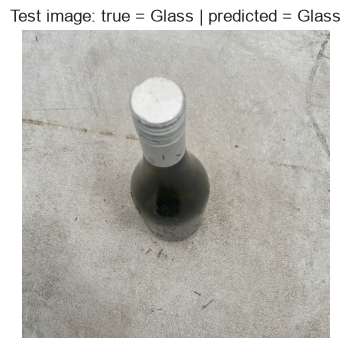

Input (image): finalist\realwaste\realwaste-main\RealWaste\Glass\Glass_235.jpg
Category: Glass (confidence 0.96, via cnn)
Instructions:
- Broken glass should be wrapped and labeled before disposal.
Preparation Instructions:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain
Grounding 1.00 | fallback False | timings {'classification_ms': 254.1, 'generation_ms': 2990.1}
  source: Glass Recycling Guidelines - Preparation Instructions (effective 2023-01-24, score 0.729)
  source: Glass Recycling Guidelines - Benefits (effective 2023-01-24, score 0.652)
  source: Glass Resident Disposal Instructions - Resident disposal instructions (effective n/a, score 0.65)


In [48]:
rng = np.random.RandomState(SEED)
test_by_class = defaultdict(list)
for p, y in zip(test_p, test_y):
    test_by_class[y].append(p)

img_rows, img_results = [], {}
for y, c in enumerate(class_names):
    p = test_by_class[y][rng.randint(len(test_by_class[y]))]
    t0 = time.perf_counter()
    r = waste_assistant(image=p)
    img_results[c] = (p, r)
    img_rows.append({"true": c, "predicted": r.get("category"), "correct": r.get("category") == c,
                     "confidence": r.get("confidence"), "low_conf_warning": r.get("low_confidence"),
                     "fallback": r.get("used_fallback"), "status": r["status"],
                     "total_s": round(time.perf_counter() - t0, 2)})
img_test_df = pd.DataFrame(img_rows)
display(img_test_df)
print(f"Assistant image accuracy on this sample: {img_test_df['correct'].mean():.0%}")

p, r = img_results["Glass"]
with Image.open(p) as im:
    plt.figure(figsize=(4, 4))
    plt.imshow(im.convert("RGB"))
    plt.axis("off")
    plt.title(f"Test image: true = Glass | predicted = {r.get('category')}")
    plt.show()
show_result(r)

### 5.6 Standard Test Cases: Text Descriptions

In [49]:
for d in ["empty plastic water bottle with cap removed",
          "flattened cardboard shipping box, clean and dry",
          "clear glass jam jar with metal lid"]:
    print("=" * 90)
    show_result(waste_assistant(description=d), show_sources=False)

Input (text): empty plastic water bottle with cap removed
Category: Metal (confidence 1.00, via distilbert)
Instructions:
- Ensure it is clean and empty before recycling.
Grounding 1.00 | fallback False | timings {'classification_ms': 112.7, 'generation_ms': 3464.4}
Input (text): flattened cardboard shipping box, clean and dry
Category: Cardboard (confidence 1.00, via distilbert)
Instructions:
- Break down large boxes to save space.
Preparation Instructions:
  - Remove all non-cardboard packaging
  - Flatten boxes to save space
  - Keep dry and clean
Grounding 1.00 | fallback False | timings {'classification_ms': 115.9, 'generation_ms': 3033.1}
Input (text): clear glass jam jar with metal lid
Category: Metal (confidence 1.00, via distilbert)
Instructions:
- Ensure it is clean and empty before recycling.
Preparation Instructions:
  - Rinse containers to remove food residue
  - Crush cans if possible to save space
  - Remove non-metal components
Grounding 1.00 | fallback False | timings 

### 5.7 Edge Cases and Robustness

Each case states the expected status, and the table reports whether the assistant behaved as expected. The cases cover:

- invalid calls: no input, both inputs, an empty description, a wrong type;
- file problems: a missing file and a **corrupt** file with an image extension;
- difficult but valid inputs: non-waste gibberish (should succeed, with a low-confidence warning), an over-long description (truncated with a warning), typos and capitals, a multi-material item, and a resident's own question.

In [50]:
with open("corrupt_test.jpg", "w") as f:
    f.write("this is not really an image")

edge_cases = [
    ("No input", {}, "error"),
    ("Both inputs", dict(image=test_p[0], description="plastic bottle"), "error"),
    ("Empty description", dict(description="   "), "error"),
    ("Wrong input type", dict(image=12345), "error"),
    ("Missing image file", dict(image="does_not_exist.jpg"), "error"),
    ("Corrupt image file", dict(image="corrupt_test.jpg"), "error"),
    ("Non-waste gibberish", dict(description="asdfgh qwerty zxcv"), "ok"),
    ("Very long description", dict(description="old plastic bottle " * 60), "ok"),
    ("Typos + capitals", dict(description="EMPTY PLASTIK WATTER BOTLE"), "ok"),
    ("Multi-material item", dict(description="glass jar with a metal lid and a paper label"), "ok"),
    ("Resident's own question", dict(description="pizza box with grease stains",
                                     question="Can I recycle a greasy pizza box?"), "ok"),
]
edge_rows = []
for name, kwargs, expected in edge_cases:
    r = waste_assistant(**kwargs)
    edge_rows.append({"case": name, "expected": expected, "status": r["status"],
                      "passed": r["status"] == expected,
                      "detail": r.get("error") if r["status"] == "error"
                                else f"{r['category']} ({r['confidence']:.2f}); warnings: {len(r['warnings'])}"})
edge_df = pd.DataFrame(edge_rows)
display(edge_df)
print(f"Edge cases passed: {edge_df['passed'].sum()}/{len(edge_df)}")
os.remove("corrupt_test.jpg")

,case,expected,status,passed,detail
0,No input,error,error,True,Provide either an image or a description.
1,Both inputs,error,error,True,Provide only one input: an image or a descript...
2,Empty description,error,error,True,Description cannot be empty.
3,Wrong input type,error,error,True,Unsupported image type: int
4,Missing image file,error,error,True,Image not found: does_not_exist.jpg
5,Corrupt image file,error,error,True,File is not a readable image: corrupt_test.jpg
6,Non-waste gibberish,ok,ok,True,Miscellaneous Trash (1.00); warnings: 0
7,Very long description,ok,ok,True,Plastic (1.00); warnings: 1
8,Typos + capitals,ok,ok,True,Miscellaneous Trash (0.99); warnings: 0
9,Multi-material item,ok,ok,True,Metal (1.00); warnings: 0


Edge cases passed: 11/11


### 5.8 Feedback Loop Demonstration

A resident describes a regional item. If the model gets it wrong, they submit a correction. The **same description** is then classified correctly through the override, and the correction appears in the retraining export. Some helpfulness feedback on the image tests is simulated to show the summary report.

In [51]:
demo_text = "crisp packet"
before = waste_assistant(description=demo_text)
print(f"Before feedback: {before['category']} ({before['confidence']:.2f}) via {before['classification_source']}")

correct = "Plastic"
record_feedback(before, correct_category=correct, helpful=before["category"] == correct,
                comment="Crisp packets are plastic film")
after = waste_assistant(description=demo_text)
print(f"After feedback : {after['category']} ({after['confidence']:.2f}) via {after['classification_source']}")

# Simulated helpfulness ratings on the image tests (for demonstration only)
for c, (p, r) in img_results.items():
    if r["status"] == "ok":
        record_feedback(r, correct_category=c, helpful=r["category"] == c)

print("\nFeedback summary by predicted category:")
display(feedback_summary())
print("Rows exported for DistilBERT retraining:")
display(export_text_feedback_for_retraining())

Before feedback: Paper (0.99) via distilbert
After feedback : Plastic (1.00) via feedback_override

Feedback summary by predicted category:


,n,correction_rate,helpful_rate
predicted,,,
Cardboard,1,0.0,1.0
Glass,1,0.0,1.0
Metal,1,0.0,1.0
Miscellaneous Trash,1,1.0,0.0
Paper,2,0.5,0.5
Plastic,1,0.0,1.0
Textile Trash,2,0.5,0.5
Vegetation,1,0.0,1.0


Rows exported for DistilBERT retraining:


,description,category
0,crisp packet,Plastic


### 5.9 Efficiency: Caching

Classification is fast, and generation dominates latency. The first call for a (category, question) pair runs retrieval and generation. A repeated call is served from the cache.

In [52]:
_cached_generation.cache_clear()
t0 = time.perf_counter(); waste_assistant(description="aluminium drink can"); first = time.perf_counter() - t0
t0 = time.perf_counter(); waste_assistant(description="aluminium drink can"); second = time.perf_counter() - t0
print(f"First call: {first:.2f}s | repeated call (cached): {second:.3f}s | speed-up x{first / max(second, 1e-6):.0f}")
print(_cached_generation.cache_info())

First call: 3.78s | repeated call (cached): 0.033s | speed-up x115
CacheInfo(hits=1, misses=1, maxsize=256, currsize=1)


## Conclusions, Limitations and Next Steps

**What was built**

- **Data:** a full-dataset image audit over 4,752 images (integrity, resolution, lighting, sharpness, background, duplicates) plus text and policy EDA. Stratified 70/15/15 splits with no overlap (3,326 / 713 / 713), duplicate removal before splitting (5,000 -> 4,939 text rows), and 76 retrieval chunks.
- **CNN:** EfficientNetB0 transfer learning with correct preprocessing, augmentation and class weights; four architecture experiments, where the EffB0 256-unit head won at 0.8331 validation accuracy ahead of MobileNetV2 at 0.7686; head training to 0.8696; fine-tuning to 0.8794; and a full error and confidence analysis. **Test: 0.8808 accuracy, 0.8865 macro-F1.**
- **Text:** a fully fine-tuned DistilBERT (66,960,393 trainable parameters) against a TF-IDF baseline — **1.0000 vs 0.9960 test accuracy** — with a near-duplicate analysis showing **19.7%** of test items have a training neighbour at cosine >= 0.8, and a 16-item challenge set where **both models score 92.3%** and fail the same misspelled item.
- **RAG:** 76 section-aware chunks plus resident disposal instructions, cosine retrieval benchmarked against two alternatives, a Flan-T5-small fine-tuned from **ROUGE-L 0.083 to 0.780**, five decoding strategies compared, and sentence-level grounding verification with an extractive fallback that triggers on **100%** of evaluation items.
- **Assistant:** one validated entry point with stage-aware errors (11/11 edge cases pass, including corrupt files and missing paths), confidence warnings, cached generation, source citations with effective dates, and a persistent feedback loop that corrects text predictions immediately and produces retraining data. On held-out test images it agrees with the CNN on **6 of 8 (78%)**.

**Limitations**

1. The text data is synthetic and templated, so test accuracy overstates real-world performance. The challenge set (92.3%) is the more honest signal, and the 19.7% near-duplicate rate quantifies the gap.
2. RealWaste images come from one facility. Residents' phone photos will differ in background and lighting, so 0.8808 is optimistic.
3. **The generator does not currently earn its place.** Fine-tuning lifted ROUGE-L to 0.780 but grounding fell to 0.047, so the safeguard suppresses the output on 100% of cases and the assistant serves extractive policy text instead. The 0.780 should never be quoted without the 1.000 fallback rate.
4. **Dense retrieval is unvalidated.** Both embedding variants returned an identical 0.111 on Hit@1, Hit@3 and MRR, which is not a plausible measurement. The benchmark also does not exercise the category-filtered path the assistant actually uses, so retrieval quality is currently unmeasured rather than measured-and-poor.
5. **Neither confidence gate catches its own failure mode.** The two wrong image predictions scored 0.699 and 0.604 against a 0.6 threshold, and DistilBERT was 0.986 confident on its one challenge-set failure. Raising the thresholds would catch these at the cost of coverage.
6. Word-overlap grounding cannot detect negation or numeric errors.
7. The policies cover a single jurisdiction and the newest is dated 2023-11-04, so effective dates are surfaced for verification.
8. All results are single-seed (42) on one split; no confidence intervals are reported.

**Next steps:** collect real resident photos and descriptions through the feedback loop; re-run the retrieval benchmark against the category-filtered path actually used in production and repair the dense arm; test a larger generator such as Flan-T5-base, or replace generation with extractive sentence selection; add an NLI-based factuality check to catch negation errors; raise the confidence thresholds to around 0.7 and measure the coverage cost; and add a "not sure" route that asks the resident a clarifying question for multi-material items such as "crisp packet".